## Trabajo Práctico: Redes Neuronales
El objetivo de este trabajo es desarrollar y evaluar modelos basados en redes neuronales,
incorporando técnicas de ablación para entender el impacto de diversas modificaciones en
el proceso de entrenamiento y en la capacidad de generalización del modelo. No se permite
usar librerías de machine learning como scikit-learn o PyTorch, a menos que sea pedido
explícitamente en el enunciado del ejercicio.

In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Análisis y Preprocesamiento de Datos
- El dataset que vamos a utilizar es similar a MNIST pero con caracteres japoneses.
- Son imágenes de 28 × 28 con 49 clases posibles.
- Examinar el dataset y visualizar al menos 3 imágenes. 
- Dividir el conjunto de datos en tres subconjuntos: Train, Validation y Test.
- Dividir todos los valores por 255, para que el máximo sea 1.

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from src.preprocessing import *
from src.plots import *
from src.neural_network import *
from src.improved_neural_network import *
from src.experiment import *
from src.utils import *

from src.pytorch_network import PyTorchNetwork

In [3]:
X_images = np.load("data/X_images.npy")
y_images = np.load("data/y_images.npy")

print("Forma de X_images:", X_images.shape)
print("Forma de y_images:", y_images.shape)
print("Número de clases únicas:", len(np.unique(y_images)))

Forma de X_images: (5000, 784)
Forma de y_images: (5000,)
Número de clases únicas: 49


1. Una visión clara de la distribución de clases para detectar posibles desbalances
2. Estadísticas sobre los valores de píxeles para entender las propiedades generales de las imágenes
3. Imágenes "promedio" de cada clase para visualizar sus características distintivas
4. Un análisis de complejidad por clase para ver cuáles pueden ser más difíciles de clasificar
5. Múltiples ejemplos de cada clase para comprender mejor la variabilidad dentro de cada categoría

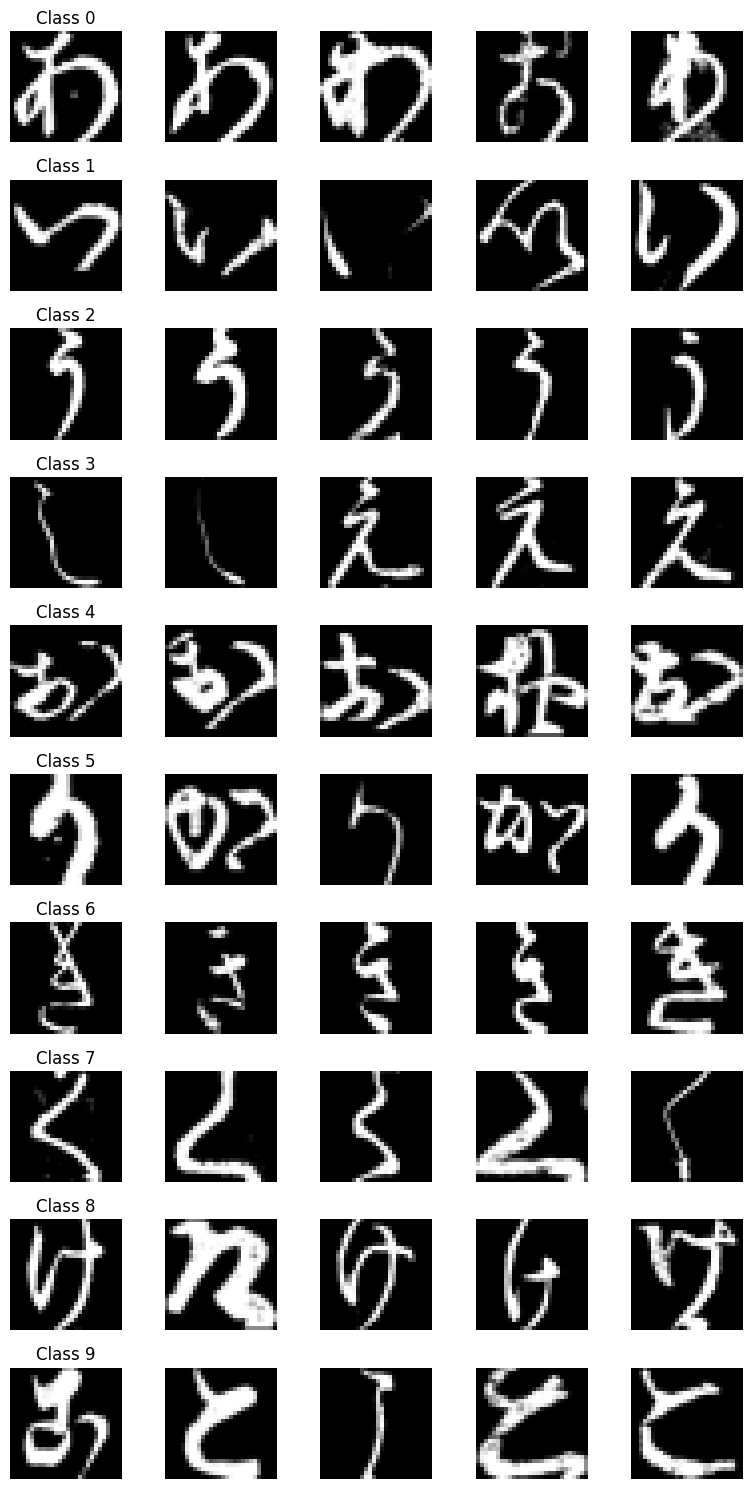

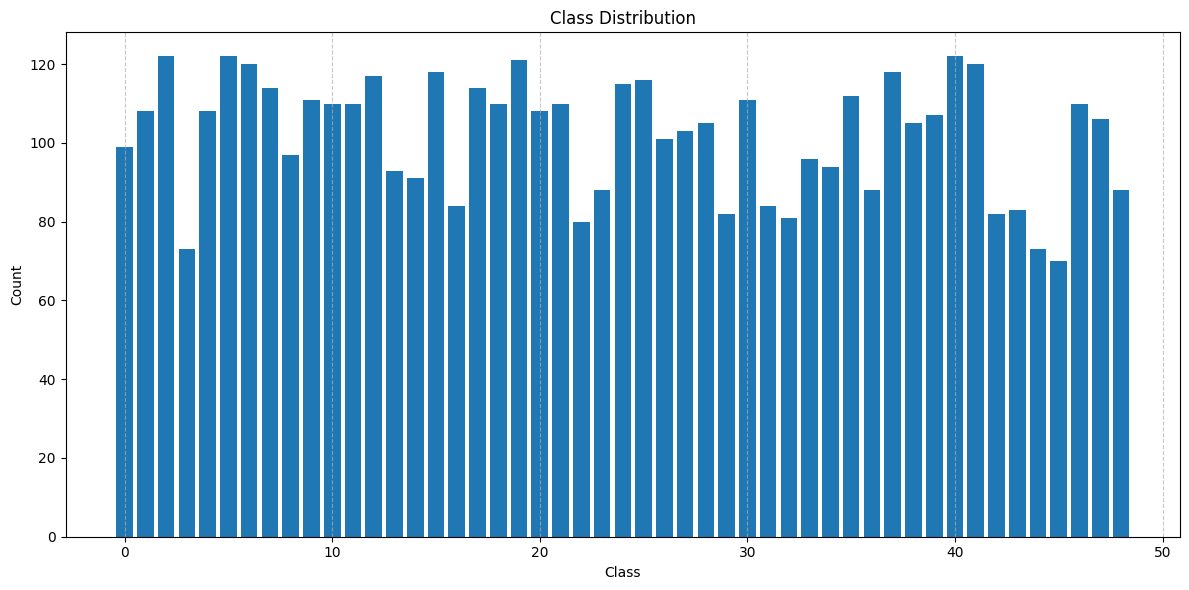

Most common class: 40 with 122 samples
Least common class: 45 with 70 samples
Class imbalance ratio (most common / least common): 1.74


In [ ]:
visualize_samples(X_images, y_images, num_samples=5, num_classes=10, figsize=(8, 15))
plot_class_distribution(y_images)

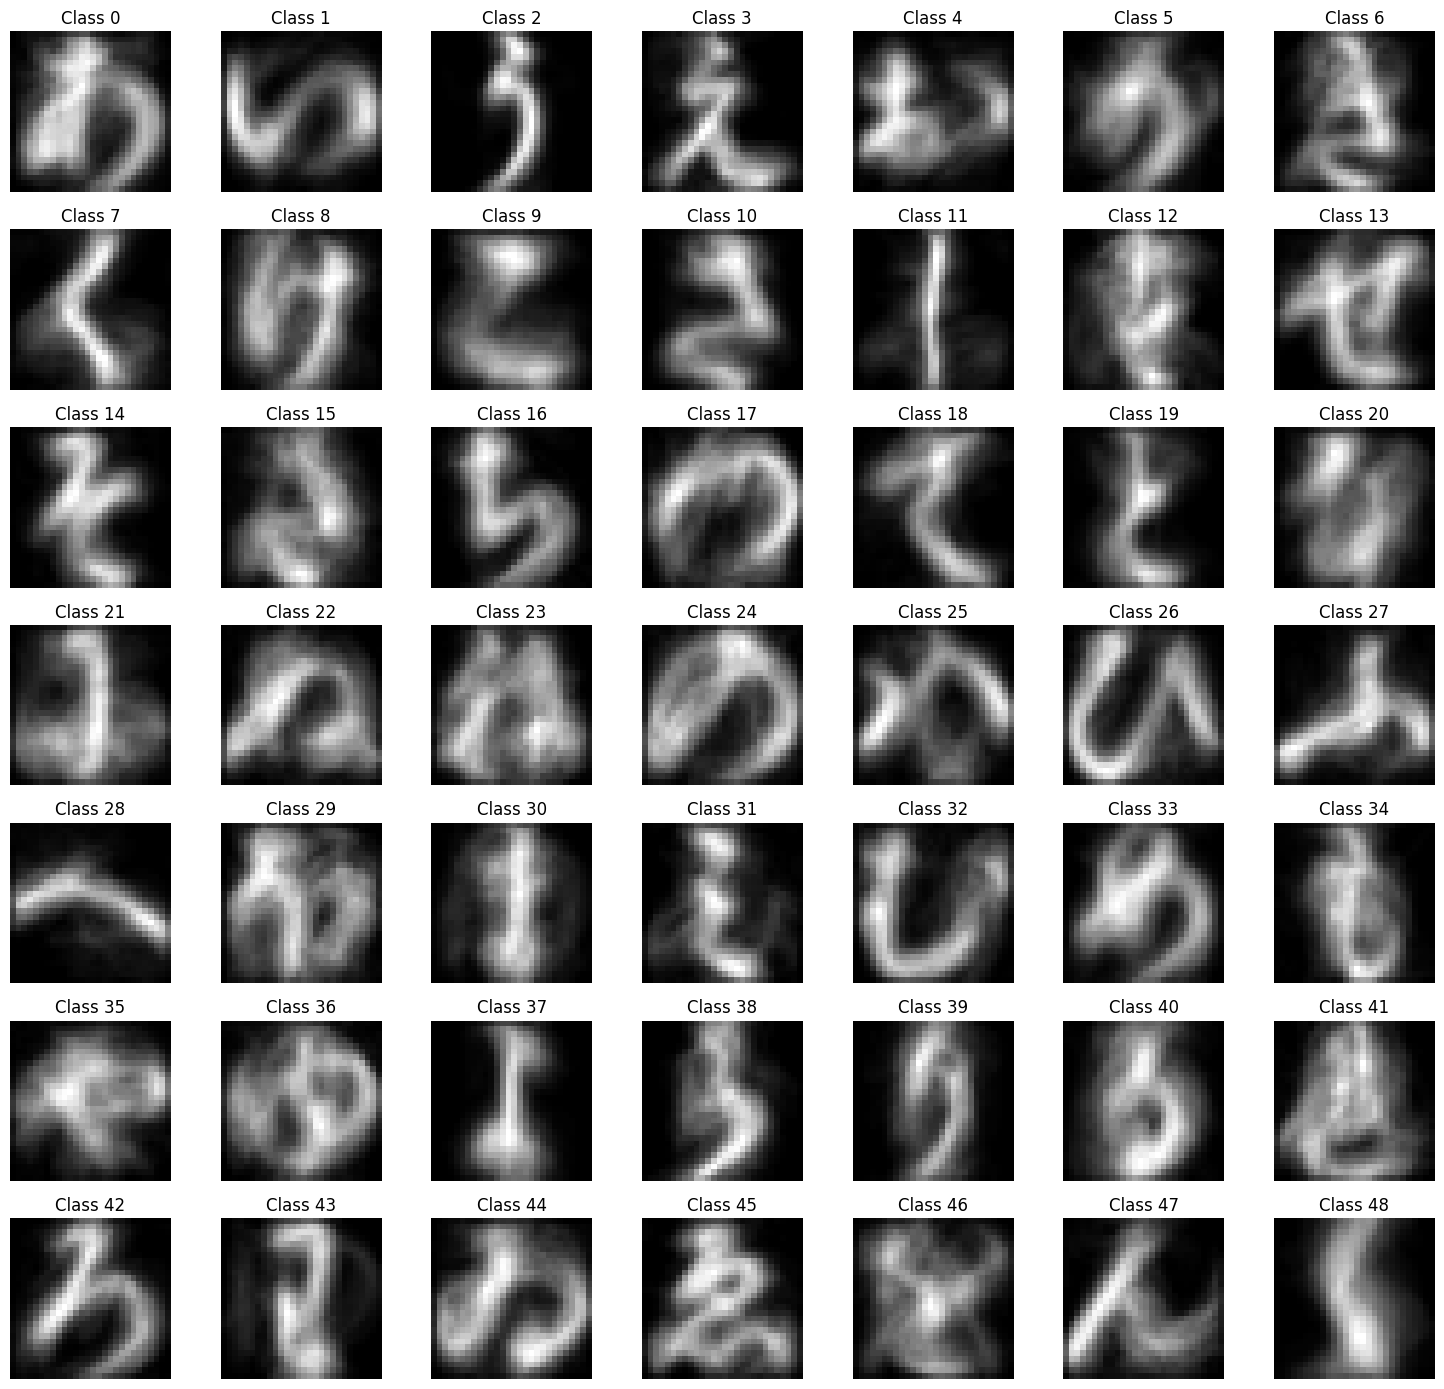

In [68]:
plot_class_averages(X_images, y_images, num_classes=49)

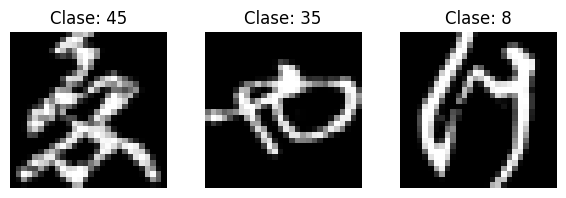

In [5]:
plt.figure(figsize=(6, 2))
for i in range(3):
    plt.subplot(1, 3, i+1)
    idx = np.random.randint(0, len(X_images))
    img = X_images[idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Clase: {y_images[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X_images / 255.0 , y_images, train_ratio=0.8 * 0.8, val_ratio=0.8 * 0.2, test_ratio=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {len(y_train)}")
print(f"X_val: {X_val.shape}, y_val: {len(y_val)}")
print(f"X_test: {X_test.shape}, y_test: {len(y_test)}")
print(f"Rango de valores en X_train: [{X_train.min()}, {X_train.max()}]")

X_train: (3197, 784), y_train: 3197
X_val: (802, 784), y_val: 802
X_test: (1001, 784), y_test: 1001
Rango de valores en X_train: [0.0, 1.0]


### 2. Implementación y Entrenamiento de una Red Neuronal Básica
- Implementar una red neuronal con L capas ocultas cada con M (l) nodos confunción de activación ReLU (en las capas ocultas) y activación softmax para la capa de salida.
- Implementar un algoritmo para entrenar dicha red, mediante backpropagation y gradiente descendiente estándar, utilizando como función de costo la cross-entropy. 
NOTA: El algoritmo backpropagation debe sera adaptado para el caso de clasificación multi-clase con función de activación softmax para la capa de salida y función de costo cross-entropy.
- Entrenar una red neuronal con 2 capas ocultas, con 100 y 80 nodos respectivamente, y graficar la evolución de la función de costo (cross-entropy) sobre los conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a este modelo M0.
Reportar las siguientes métricas de performance, sobre los conjuntos de entrenamiento y validación, para el modelo base entrenado:
    - Accuracy
    - Cross-Entropy 
    - Matriz de Confusión

Epoch: [=================================================>] 100% - train_loss: 0.6248 - train_acc: 0.8661 - val_loss: 1.7288 - val_acc: 0.5736
Model successfully saved to modelos/model_M0.pkl


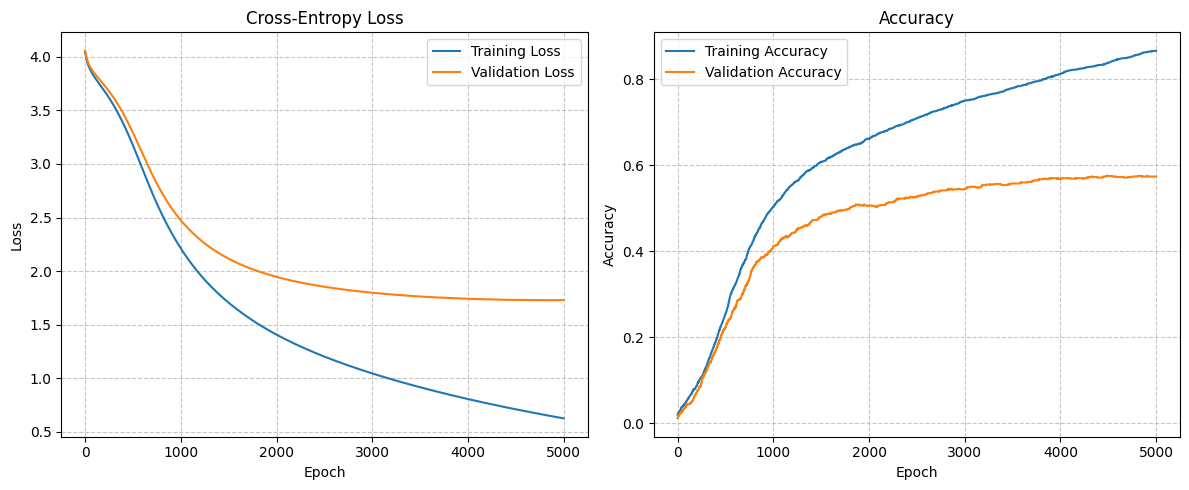

In [7]:
input_size = X_train.shape[1]
output_size = len(np.unique(y_train))
layer_sizes = [input_size, 100, 80, output_size]

model_M0 = NeuralNetwork(layer_sizes, learning_rate=0.01)

history_M0 = model_M0.train(X_train, y_train, X_val, y_val, epochs=5000)
save_model(model_M0, "model_M0.pkl")

plot_learning_curves(history_M0)

In [8]:
train_pred = model_M0.forward(X_train)
val_pred = model_M0.forward(X_val)

train_loss = model_M0.cross_entropy_loss(y_train, train_pred)
val_loss = model_M0.cross_entropy_loss(y_val, val_pred)

train_accuracy = model_M0.accuracy(y_train, train_pred)
val_accuracy = model_M0.accuracy(y_val, val_pred)

print(f"Performance Metrics for Model M0:")
print(f"Training Set - Accuracy: {train_accuracy:.4f}, Cross-Entropy: {train_loss:.4f}")
print(f"Validation Set - Accuracy: {val_accuracy:.4f}, Cross-Entropy: {val_loss:.4f}")


Performance Metrics for Model M0:
Training Set - Accuracy: 0.8661, Cross-Entropy: 0.6248
Validation Set - Accuracy: 0.5736, Cross-Entropy: 1.7288


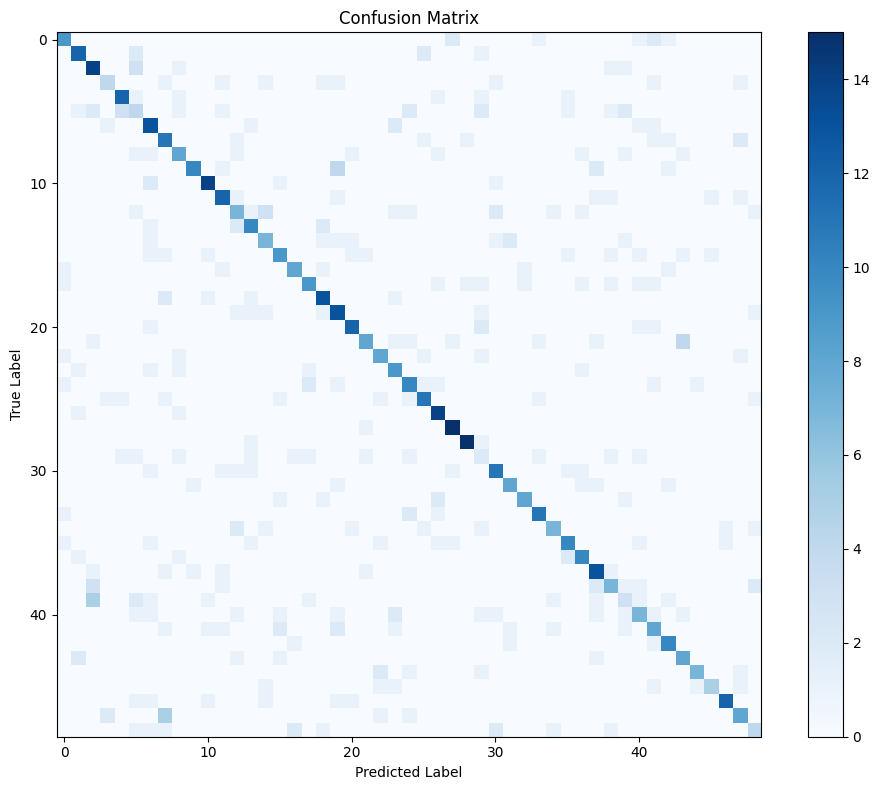

In [9]:
conf_matrix = model_M0.confusion_matrix(y_val, val_pred)
plot_confusion_matrix(conf_matrix)

### 3. Implementación y Entrenamiento de una Red Neuronal Avanzada
- Implementar las siguientes mejoras al algoritmo de entrenamiento, y para cada una reportar el efecto observado sobre el tiempo de entrenamiento y la performance del modelo resultante.
    - Rate scheduling lineal (con saturación) y exponencial.
    - Mini-batch stochastic gradient descent.
    - Optimizador ADAM.
    - Regularización L2.
    - Regularización mediante early stopping.
    - OPCIONAL: Regularización mediante dropout.
    - OPCIONAL: batch normalization.
- Explorar cambios en la arquitectura de la red (es decir, la cantidad de capas ocultas y unidades ocultas por capa), y los hiperparámetros (cada uno de los items en la lista anterior tiene una serie de parámetros que podemos variar), y determinar la configuración que funcione mejor (menor error de validación).
Llamaremos a este modelo M1.

In [10]:
input_size = X_train.shape[1] 
output_size = len(np.unique(y_train))
layer_sizes = [input_size, 100, 80, output_size]

In [11]:
experiments = [
    {
        'name': 'Baseline (SGD)',
        'learning_rate': 0.01,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None, 
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    }, {
        'name': 'Linear Rate Scheduling',
        'learning_rate': 0.01,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None,
        'optimizer': 'sgd',
        'lr_schedule': 'linear',
        'early_stopping_patience': None
    },{
        'name': 'Exponential Rate Scheduling',
        'learning_rate': 0.01,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None,
        'optimizer': 'sgd',
        'lr_schedule': 'exponential',
        'early_stopping_patience': None
    },{
        'name': 'Mini-batch SGD',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64, 
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'ADAM Optimizer',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'adam',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'L2 Regularization',
        'learning_rate': 0.001,
        'l2_lambda': 0.001,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'Early Stopping',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 4000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': 10  
    },{
        'name': 'Dropout',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.2,  
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'Batch Normalization',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': True,  
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'Combined Improvements',
        'learning_rate': 0.001,
        'l2_lambda': 0.0005,  
        'dropout_rate': 0.2,  
        'use_batch_norm': True,
        'epochs': 4000,
        'batch_size': 64,
        'optimizer': 'adam',
        'lr_schedule': 'exponential', 
        'early_stopping_patience': 15 
    }
]

In [12]:
results = run_experiments(X_train, y_train, X_val, y_val, ImprovedNeuralNetwork, layer_sizes, experiments)


Running experiment: Baseline (SGD)
Epoch: [=================================================>] 100% - train_loss: 1.2644 - train_acc: 0.6935 - val_loss: 1.8312 - val_acc: 0.5349 - lr: 0.0100
Best result for Baseline (SGD): val_loss = 1.8312, val_accuracy = 0.5349

Running experiment: Linear Rate Scheduling
Epoch: [=================================================>] 100% - train_loss: 1.6270 - train_acc: 0.6128 - val_loss: 2.0439 - val_acc: 0.4888 - lr: 0.0050
Best result for Linear Rate Scheduling: val_loss = 2.0439, val_accuracy = 0.4888

Running experiment: Exponential Rate Scheduling
Epoch: [=================================================>] 100% - train_loss: 1.3775 - train_acc: 0.6678 - val_loss: 1.8833 - val_acc: 0.5287 - lr: 0.0090
Best result for Exponential Rate Scheduling: val_loss = 1.8833, val_accuracy = 0.5287

Running experiment: Mini-batch SGD
Epoch: [=================================================>] 100% - train_loss: 0.1835 - train_acc: 0.9837 - val_loss: 1.9371 - 

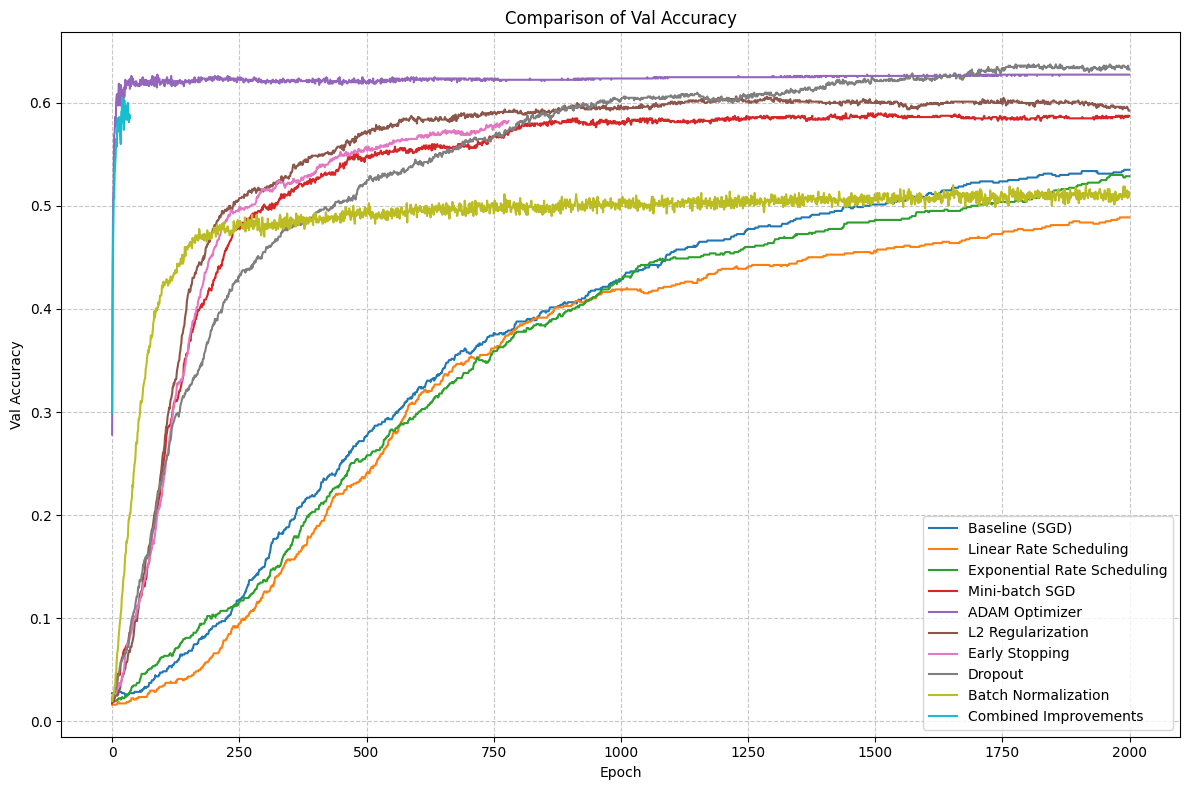

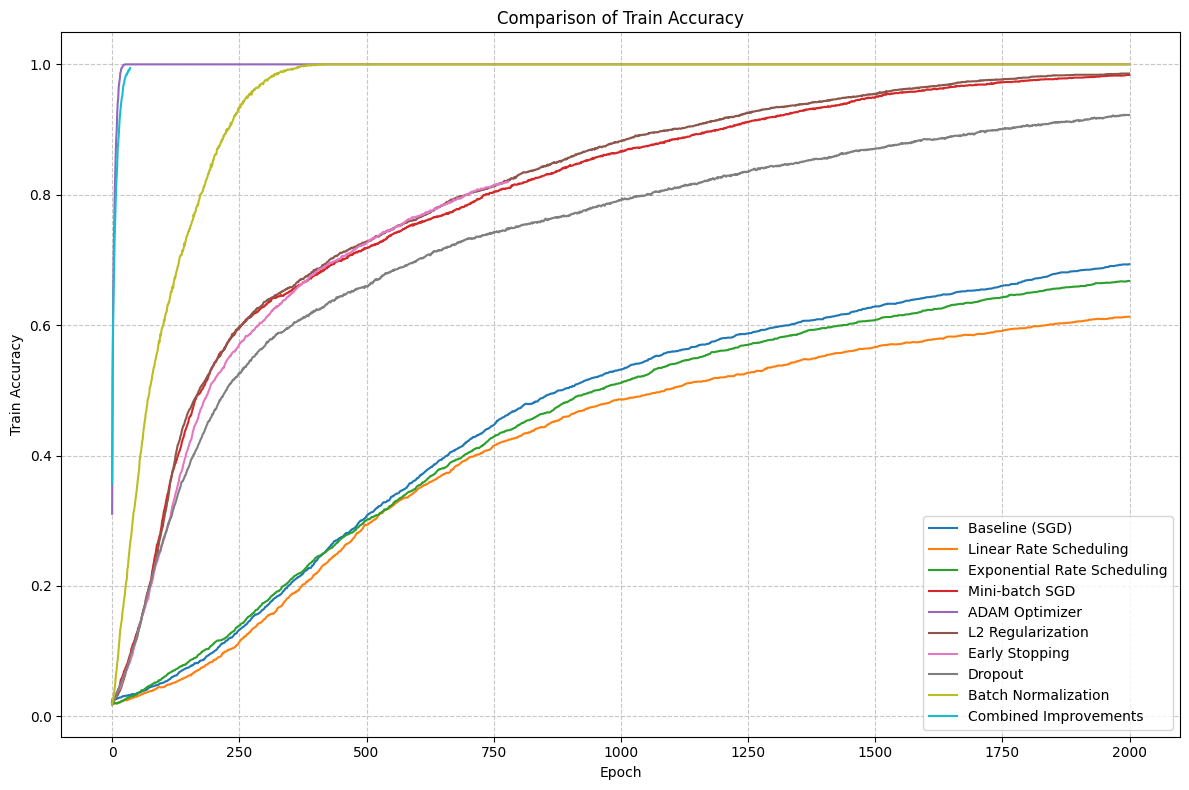

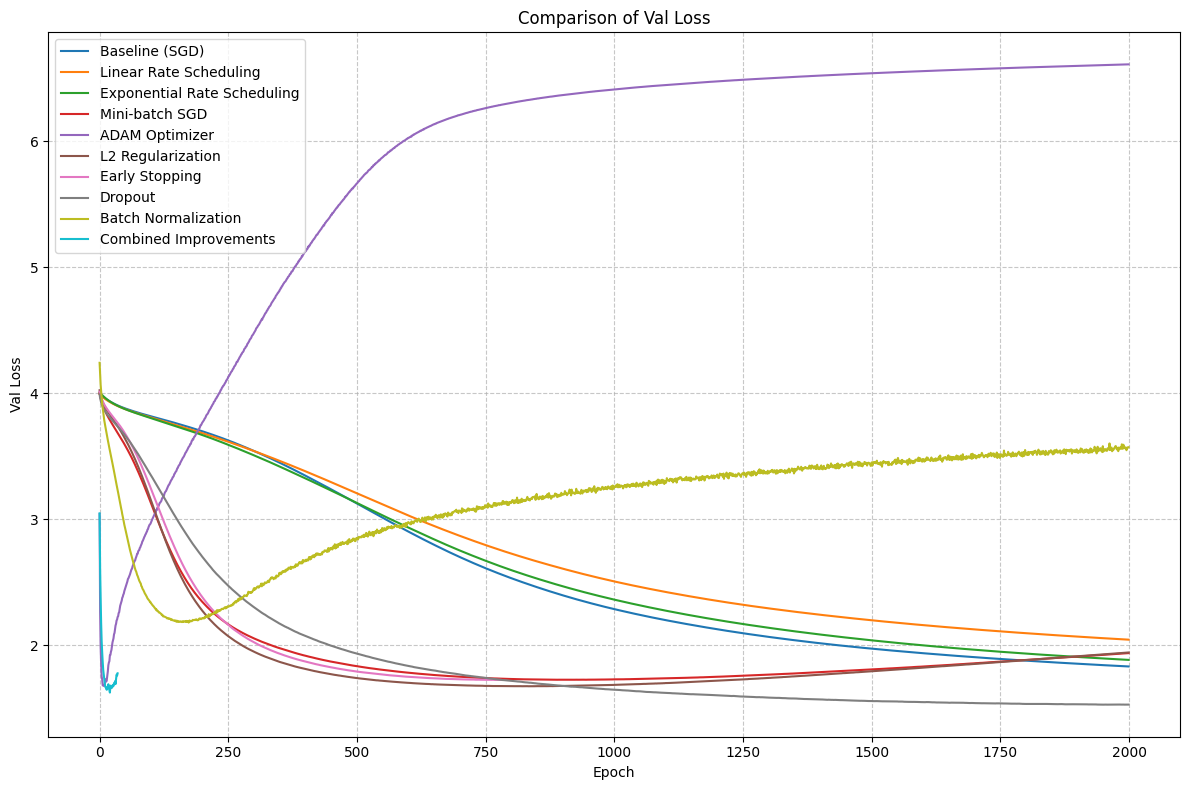

In [69]:
plot_experiment_results(results, metric='val_accuracy')
plot_experiment_results(results, metric='train_accuracy')
plot_experiment_results(results, metric='val_loss')

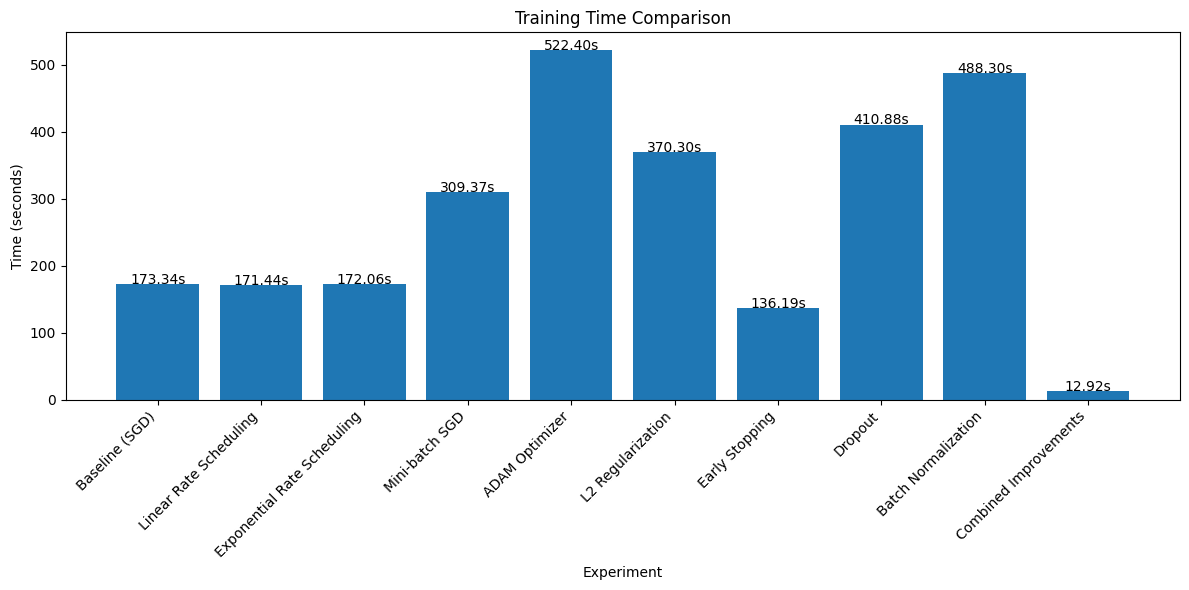

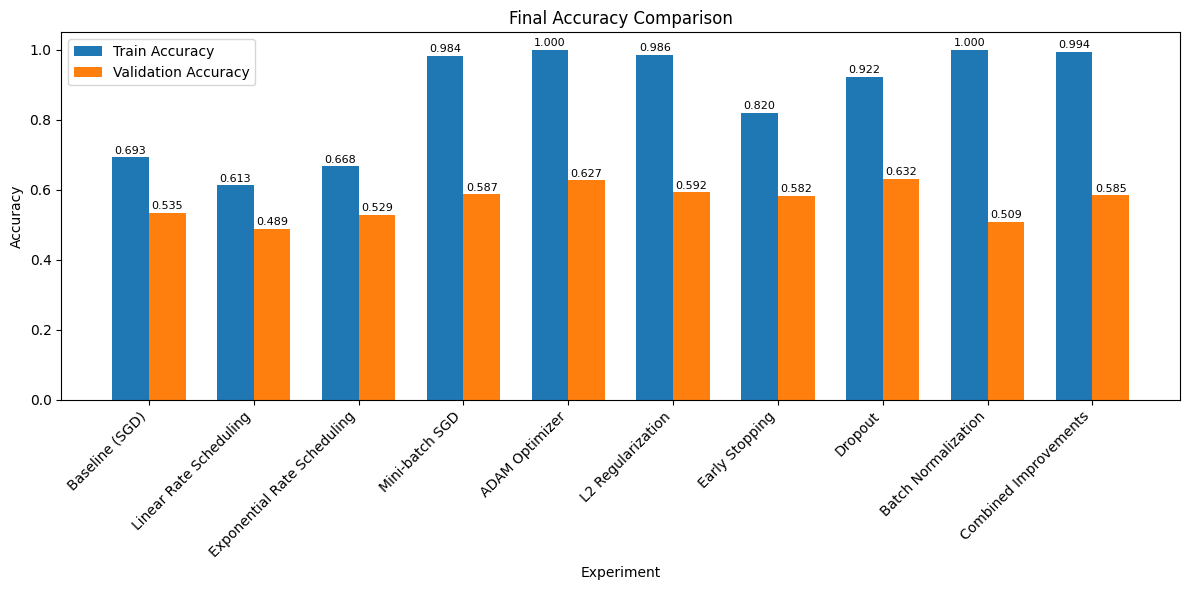

In [14]:
compare_training_times(results)
compare_final_metrics(results)

In [15]:
sorted_results = sorted(results, key=lambda x: x['final_val_accuracy'], reverse=True)

best_result = sorted_results[0]
print(f"\nBest model: {best_result['name']}")
print(f"Validation accuracy: {best_result['final_val_accuracy']:.4f}")

second_best_result = sorted_results[1]
print(f"\nSecond best model: {second_best_result['name']}")
print(f"Validation accuracy: {second_best_result['final_val_accuracy']:.4f}")


Best model: Dropout
Validation accuracy: 0.6322

Second best model: ADAM Optimizer
Validation accuracy: 0.6272


In [74]:
print("\nExploring different architectures with the best configuration...")
architectures = [
    {
        'name': 'Single Hidden Layer (200)',
        'layer_sizes': [input_size, 200, output_size]
    },{
        'name': 'Two Hidden Layers (100, 80)',
        'layer_sizes': [input_size, 100, 80, output_size]
    },{
        'name': 'Three Hidden Layers (120, 80, 60)',
        'layer_sizes': [input_size, 120, 80, 60, output_size]
    },{
        'name': 'Wide Network (200, 150)',
        'layer_sizes': [input_size, 200, 150, output_size]
    },{
        'name': 'Deep Network (100, 80, 60, 40)',
        'layer_sizes': [input_size, 100, 80, 60, 40, output_size]
    }
]

architecture_results = run_architecture_experiments(
    architectures=architectures,
    cofiguration=best_result,
    ImprovedNeuralNetwork=ImprovedNeuralNetwork,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)


Exploring different architectures with the best configuration...

Testing architecture: Single Hidden Layer (200)
Epoch: [=================================================>] 100% - train_loss: 0.5147 - train_acc: 0.9043 - val_loss: 1.4555 - val_acc: 0.6272 - lr: 0.0010

Results for Single Hidden Layer (200):
Training time: 576.28 seconds


KeyError: 'final_train_loss'

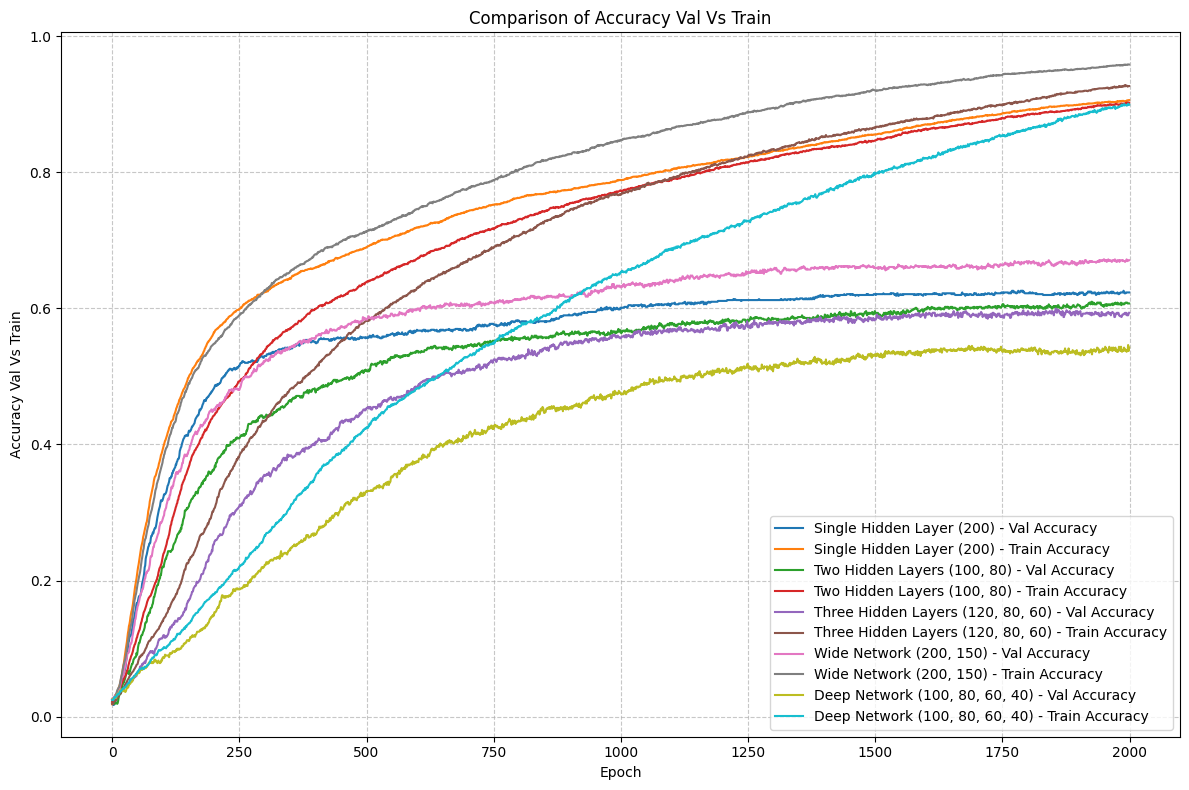

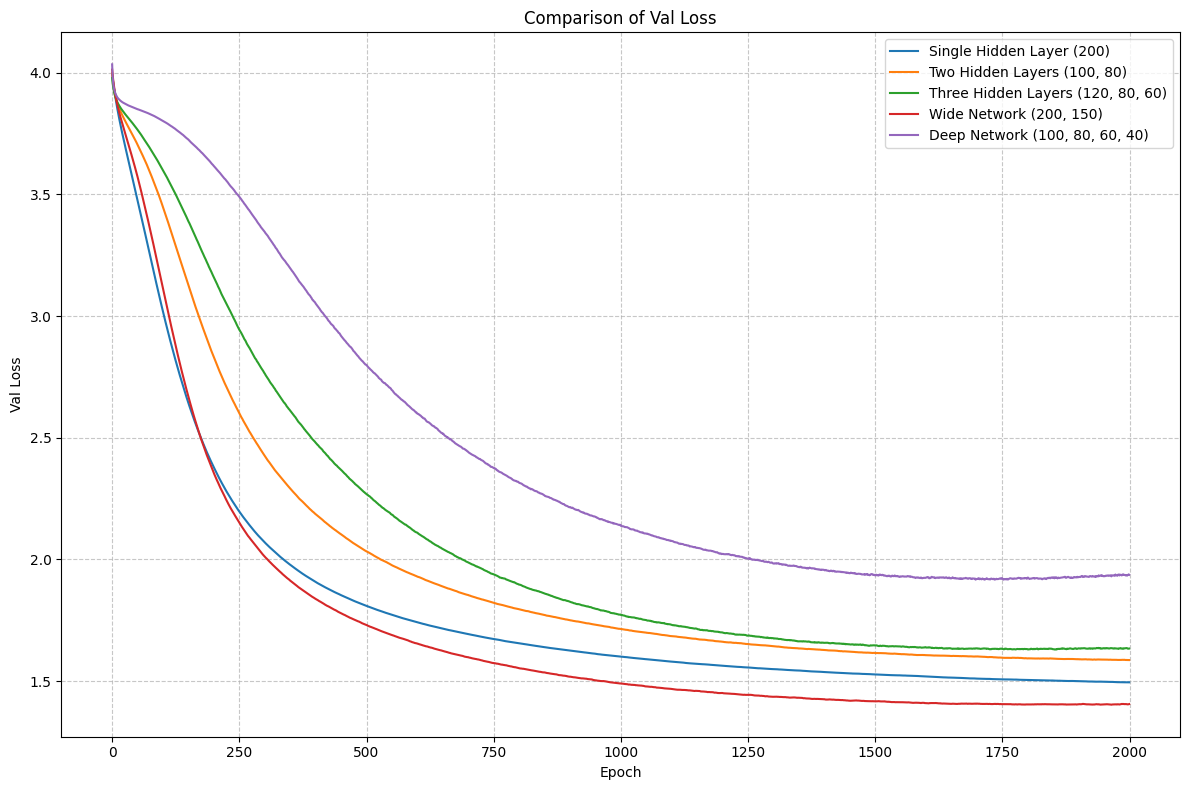

In [ ]:
plot_experiment_results(architecture_results, metric='accuracy_val_vs_train')
plot_experiment_results(architecture_results, metric='val_loss')

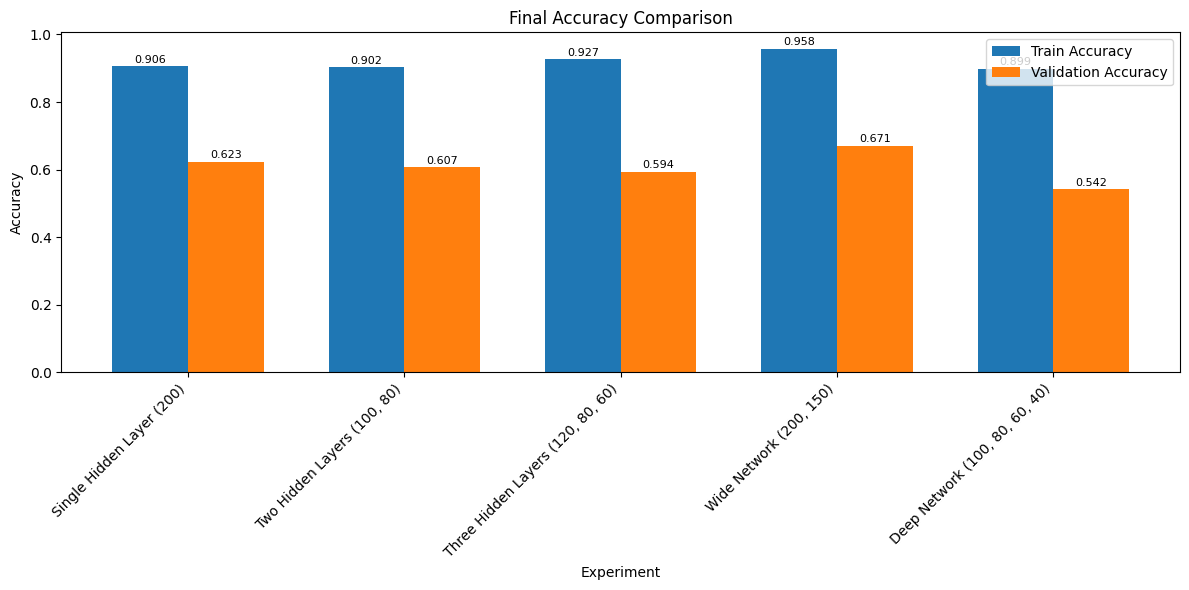


Best architecture: Wide Network (200, 150)
Validation accuracy: 0.6708


In [ ]:
compare_final_metrics(architecture_results)

best_arch_result = max(architecture_results, key=lambda x: x['final_val_accuracy'])
print(f"\nBest architecture: {best_arch_result['name']}")
print(f"Validation accuracy: {best_arch_result['final_val_accuracy']:.4f}")

In [ ]:
print("\nExploring different architectures with the second best configuration...")

architecture_results_2 = run_architecture_experiments(
    architectures=architectures,
    cofiguration=second_best_result,
    ImprovedNeuralNetwork=ImprovedNeuralNetwork,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)


Exploring different architectures with the second best configuration...

Testing architecture: Single Hidden Layer (200)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 5.1974 - val_acc: 0.6409 - lr: 0.0010

Results for Single Hidden Layer (200):
Training time: 617.74 seconds
Final train loss: 0.0000, train accuracy: 1.0000
Final val loss: 5.1974, val accuracy: 0.6409

Testing architecture: Two Hidden Layers (100, 80)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 6.2664 - val_acc: 0.6110 - lr: 0.0010

Results for Two Hidden Layers (100, 80):
Training time: 446.93 seconds
Final train loss: 0.0000, train accuracy: 1.0000
Final val loss: 6.2664, val accuracy: 0.6110

Testing architecture: Three Hidden Layers (120, 80, 60)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 6.7492 - v

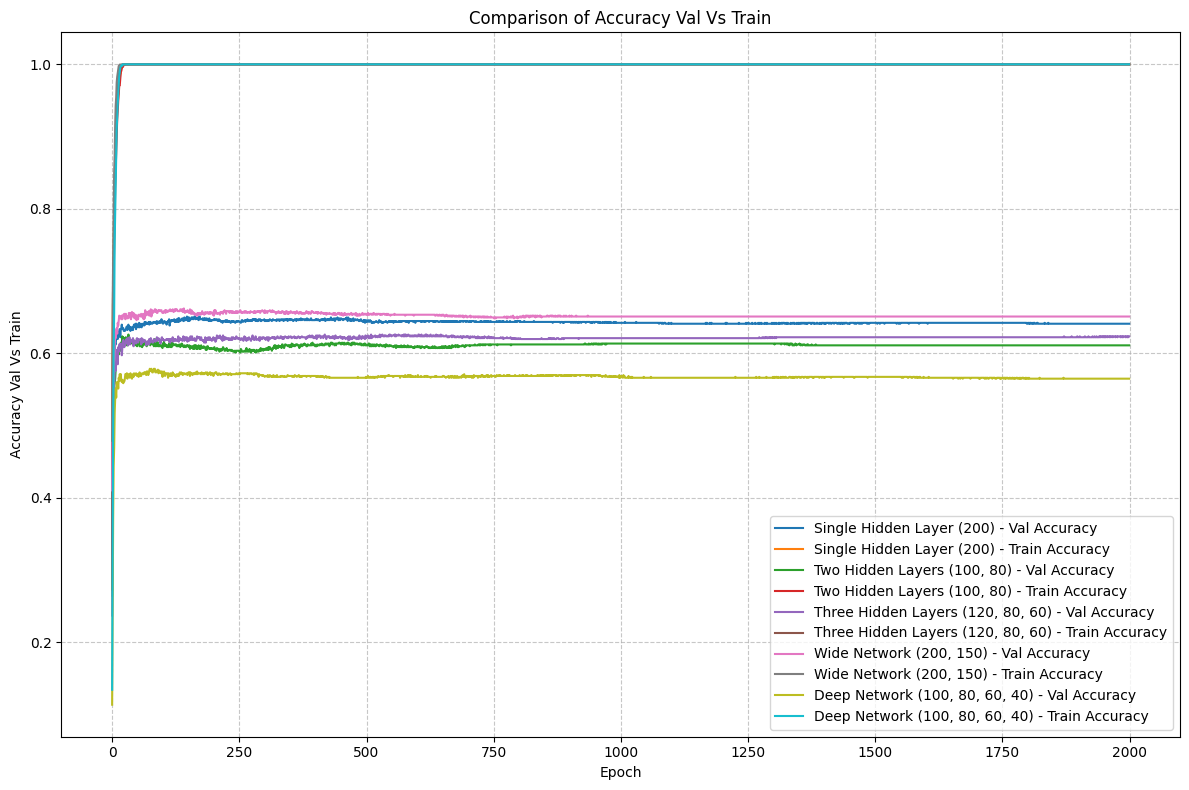

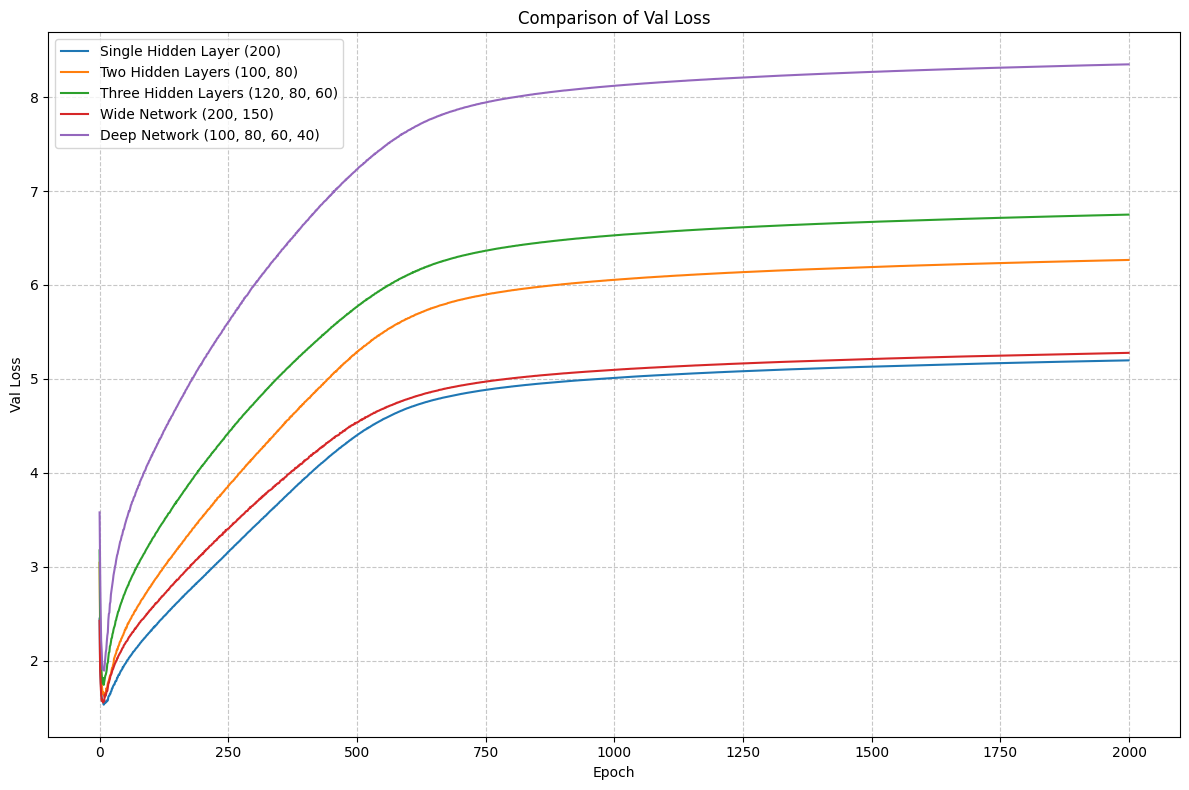

In [ ]:
plot_experiment_results(architecture_results_2, metric='accuracy_val_vs_train')
plot_experiment_results(architecture_results_2, metric='val_loss')

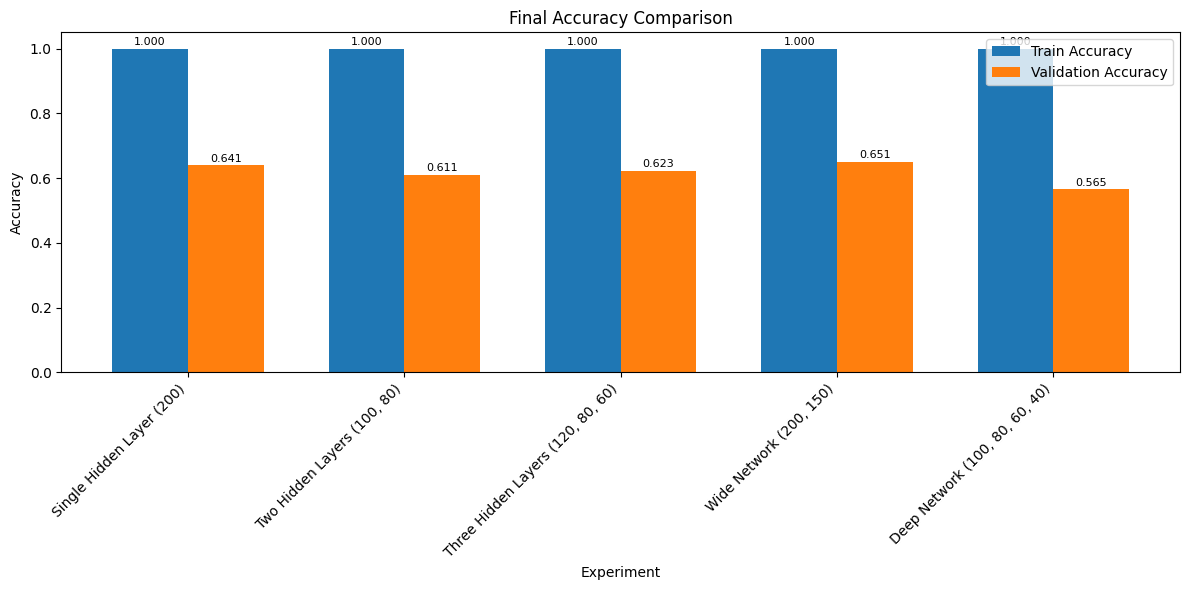


Best architecture: Wide Network (200, 150)
Validation accuracy: 0.6509


In [ ]:
compare_final_metrics(architecture_results_2)

best_arch_result_2 = max(architecture_results_2, key=lambda x: x['final_val_accuracy'])
print(f"\nBest architecture: {best_arch_result_2['name']}")
print(f"Validation accuracy: {best_arch_result_2['final_val_accuracy']:.4f}")

In [22]:
learning_rates_to_test = [0.001, 0.0005, 0.002]

lr_tuning_experiments = []

config = {
        'learning_rate': 0.001,
        'l2_lambda': 0.0,  
        'dropout_rate': 0.2,  
        'use_batch_norm': False,
        'epochs': 4000,
        'batch_size': 64,
        'optimizer': 'adam',
        'lr_schedule': 'exponential', 
        'early_stopping_patience': 15 
    }

for lr_value in learning_rates_to_test:
    lr_tuning_experiments.append(config.copy())
    lr_tuning_experiments[-1]['learning_rate'] = lr_value
    lr_tuning_experiments[-1]['name'] = f"LR_{lr_value}"

lr_tuning_results = run_experiments(X_train, y_train, X_val, y_val, ImprovedNeuralNetwork, best_arch_result['layer_sizes'], lr_tuning_experiments)


Running experiment: LR_0.001
Epoch: [>                                                 ] 0% - train_loss: 0.0436 - train_acc: 0.9966 - val_loss: 1.4910 - val_acc: 0.6771 - lr: 0.0010
Early stopping triggered at epoch 26

Best result for LR_0.001: val_loss = 1.4107, val_accuracy = 0.6521

Running experiment: LR_0.0005
Epoch: [>                                                 ] 0% - train_loss: 0.0751 - train_acc: 0.9941 - val_loss: 1.4964 - val_acc: 0.6584 - lr: 0.0005
Early stopping triggered at epoch 39

Best result for LR_0.0005: val_loss = 1.4008, val_accuracy = 0.6484

Running experiment: LR_0.002
Epoch: [>                                                 ] 0% - train_loss: 0.0228 - train_acc: 0.9959 - val_loss: 1.8211 - val_acc: 0.6496 - lr: 0.0020
Early stopping triggered at epoch 23

Best result for LR_0.002: val_loss = 1.4627, val_accuracy = 0.6334



Graficando resultados del ajuste de LR (sin dropout / l2)...


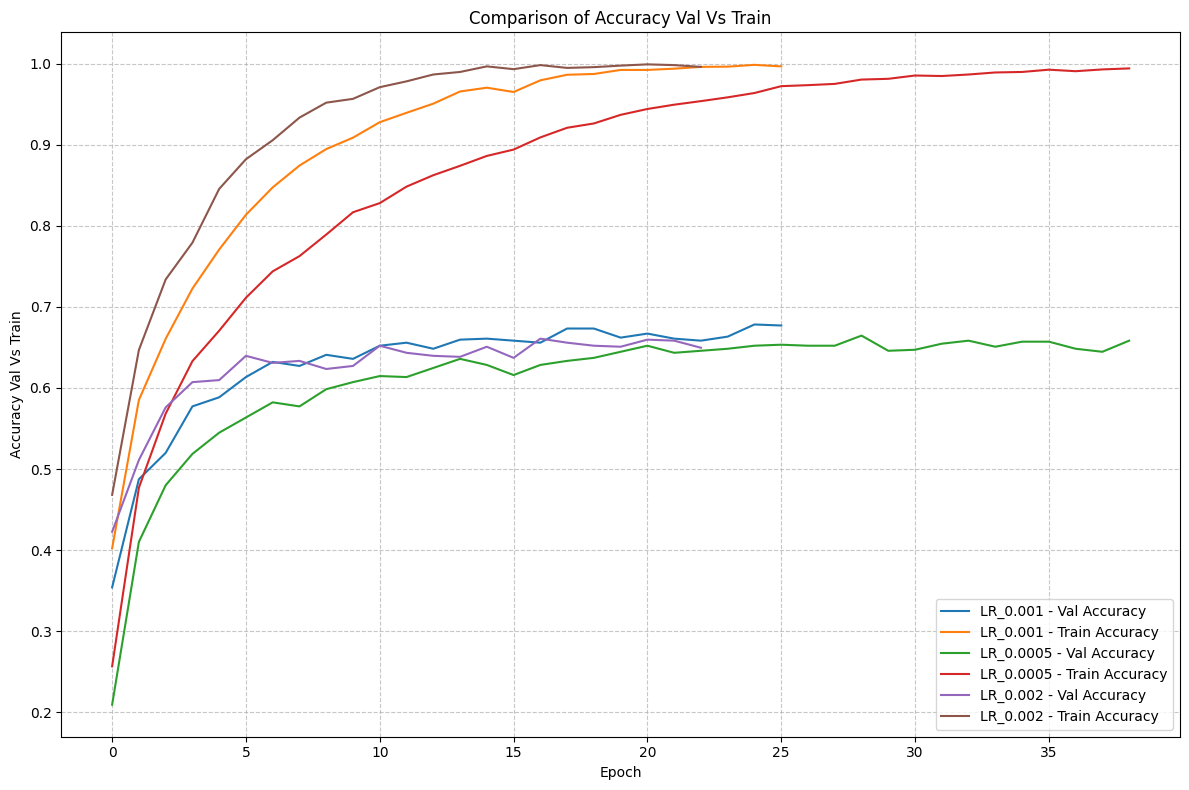

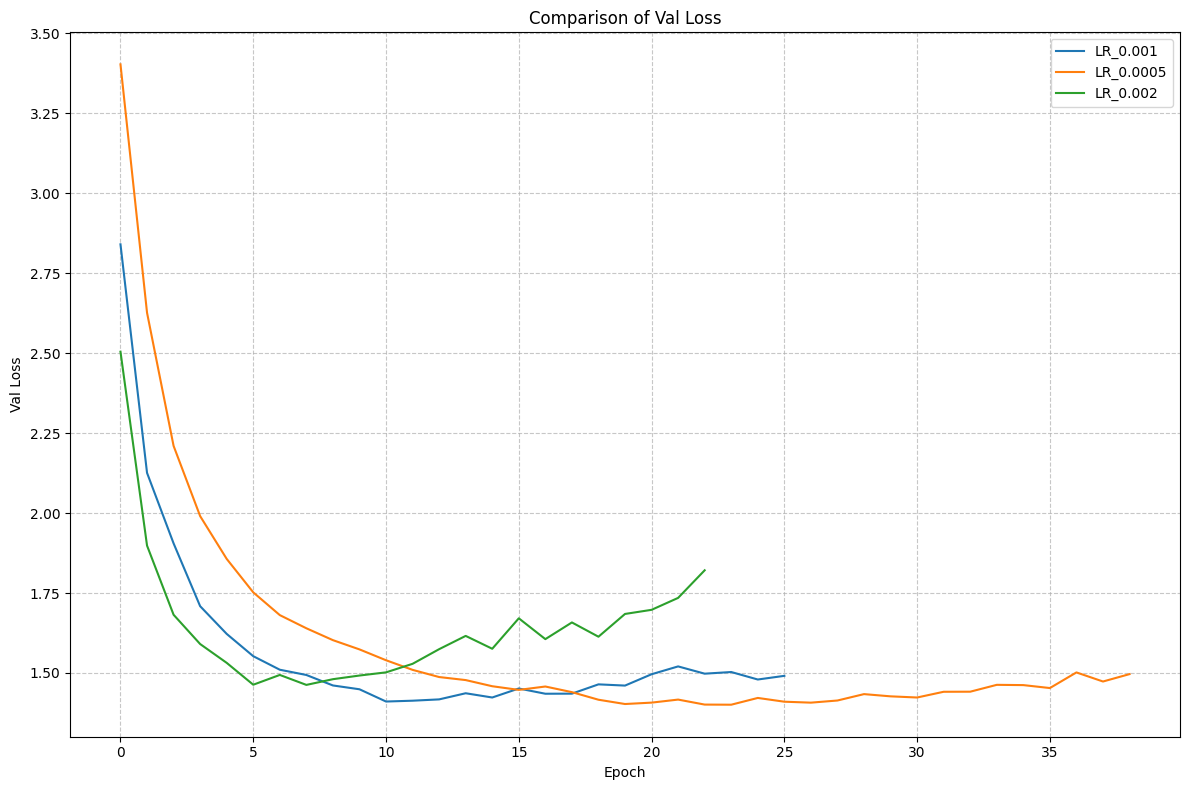

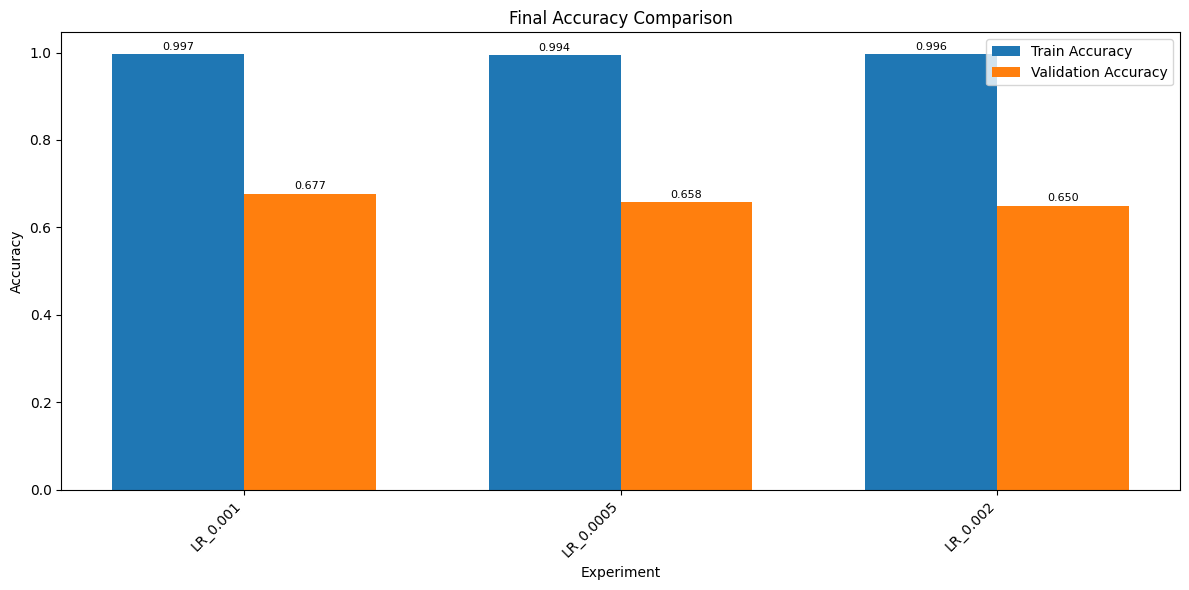


--- Mejor Modelo Después del Ajuste de Tasa de Aprendizaje (sin dropout/l2) ---
Nombre: LR_0.001
Precisión de Validación: 0.6771
Tasa de Aprendizaje: 0.001
Configuración Completa:
  learning_rate: 0.001
  l2_lambda: 0.0
  dropout_rate: 0.2
  use_batch_norm: False
  epochs: 4000
  batch_size: 64
  optimizer: adam
  lr_schedule: exponential
  early_stopping_patience: 15
  name: LR_0.001
  model: <src.improved_neural_network.ImprovedNeuralNetwork object at 0x70d0fd7d56a0>
  final_train_loss: 0.043599454467499875
  final_train_accuracy: 0.9965592743196747
  final_val_loss: 1.4910018758302466
  final_val_accuracy: 0.6770573566084788
  training_time: 11.047519445419312


In [23]:
print("\nGraficando resultados del ajuste de LR (sin dropout / l2)...")
plot_experiment_results(lr_tuning_results, metric='accuracy_val_vs_train')
plot_experiment_results(lr_tuning_results, metric='val_loss')
compare_final_metrics(lr_tuning_results)

best_lr_tuned_model = max(lr_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de Tasa de Aprendizaje (sin dropout/l2) ---")
print(f"Nombre: {best_lr_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_lr_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"Tasa de Aprendizaje: {best_lr_tuned_model.get('learning_rate', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_lr_tuned_model.items():
    if key not in ['history']:
            print(f"  {key}: {value}")

In [24]:
l2_values_to_test = [0.0001, 0.001, 0.01]

l2_tuning_experiments = []

best_lr = best_lr_tuned_model['learning_rate']

config['learning_rate']= best_lr

for l2_value in l2_values_to_test:
    l2_tuning_experiments.append(config.copy())
    l2_tuning_experiments[-1]['l2_lambda'] = l2_value
    l2_tuning_experiments[-1]['name'] = f"L2_{l2_value}"

l2_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    l2_tuning_experiments
)


Running experiment: L2_0.0001
Epoch: [>                                                 ] 0% - train_loss: 0.0219 - train_acc: 0.9997 - val_loss: 1.5642 - val_acc: 0.6683 - lr: 0.0010
Early stopping triggered at epoch 33

Best result for L2_0.0001: val_loss = 1.4216, val_accuracy = 0.6658

Running experiment: L2_0.001
Epoch: [>                                                 ] 0% - train_loss: 0.0267 - train_acc: 0.9984 - val_loss: 1.5682 - val_acc: 0.6584 - lr: 0.0010
Early stopping triggered at epoch 30

Best result for L2_0.001: val_loss = 1.3968, val_accuracy = 0.6708

Running experiment: L2_0.01
Epoch: [>                                                 ] 0% - train_loss: 0.0359 - train_acc: 0.9984 - val_loss: 1.5707 - val_acc: 0.6596 - lr: 0.0010
Early stopping triggered at epoch 29

Best result for L2_0.01: val_loss = 1.4099, val_accuracy = 0.6471



Graficando resultados del ajuste de L2...


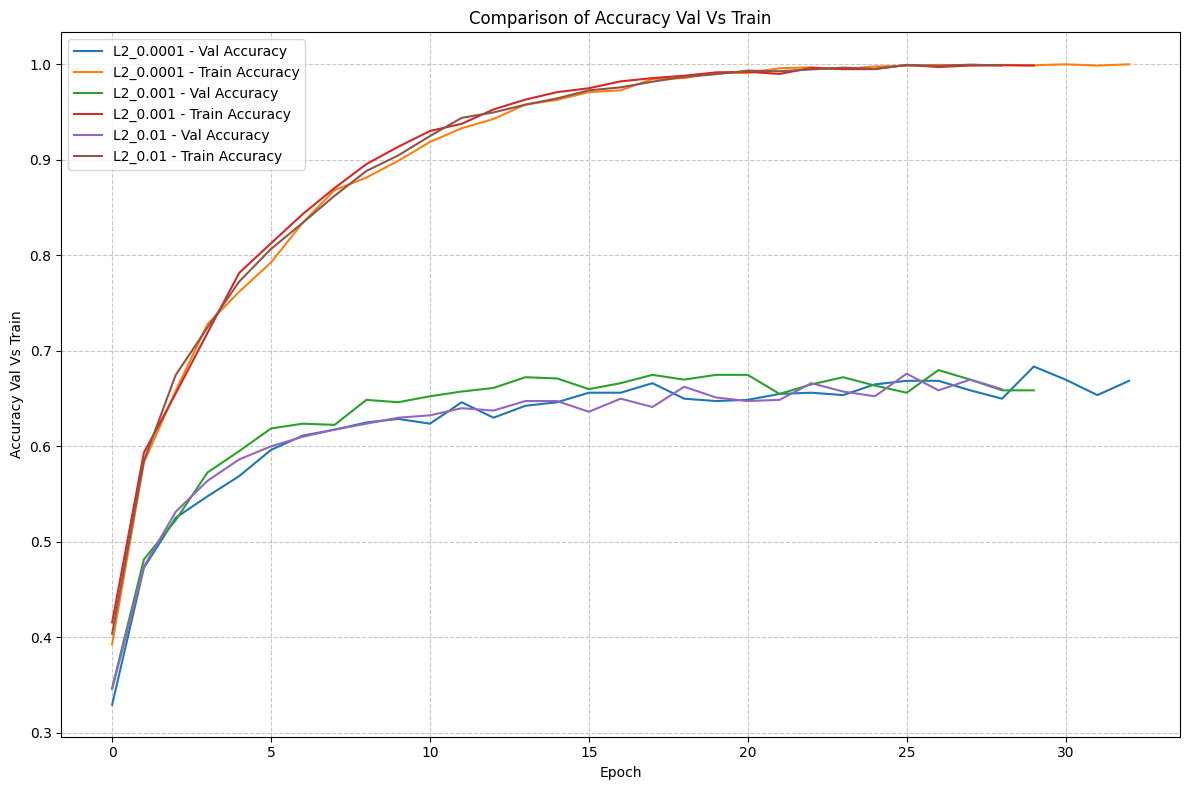

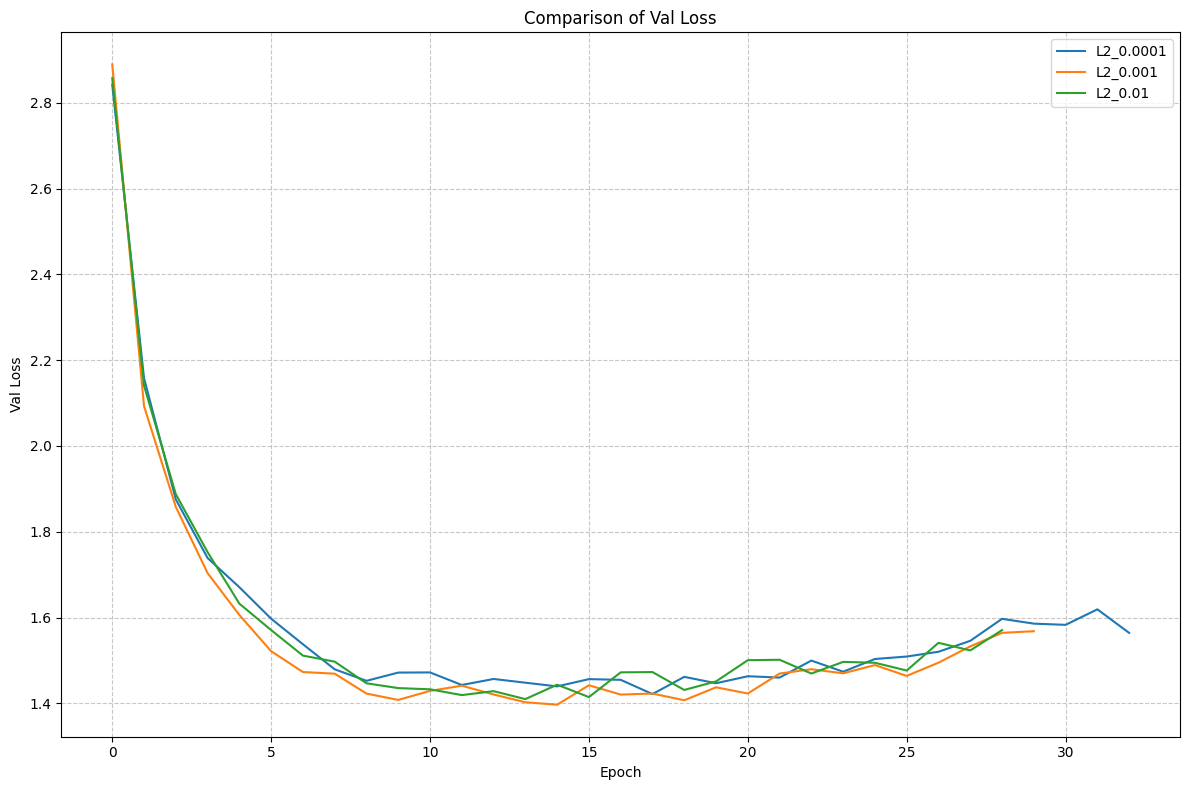

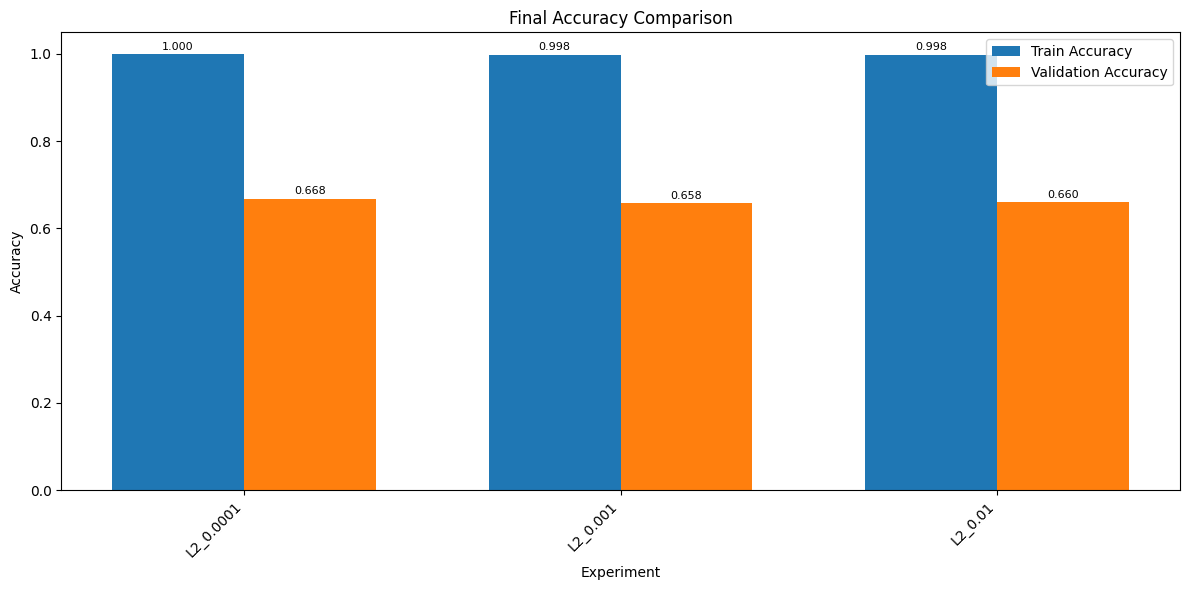


--- Mejor Modelo Después del Ajuste de L2 ---
Nombre: L2_0.0001
Precisión de Validación: 0.6683
L2 Lambda: 0.0001
Configuración Completa:
  learning_rate: 0.001
  l2_lambda: 0.0001
  dropout_rate: 0.2
  use_batch_norm: False
  epochs: 4000
  batch_size: 64
  optimizer: adam
  lr_schedule: exponential
  early_stopping_patience: 15
  name: L2_0.0001
  model: <src.improved_neural_network.ImprovedNeuralNetwork object at 0x70d0fd7d58b0>
  final_train_loss: 0.021887515367176282
  final_train_accuracy: 0.999687206756334
  final_val_loss: 1.564217158163102
  final_val_accuracy: 0.6683291770573566
  training_time: 15.3146333694458


In [25]:
print("\nGraficando resultados del ajuste de L2...")
plot_experiment_results(l2_tuning_results, metric='accuracy_val_vs_train')
plot_experiment_results(l2_tuning_results, metric='val_loss')
compare_final_metrics(l2_tuning_results)

best_l2_tuned_model = max(l2_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de L2 ---")
print(f"Nombre: {best_l2_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_l2_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"L2 Lambda: {best_l2_tuned_model.get('l2_lambda', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_l2_tuned_model.items():
    if key not in ['history']:
        print(f"  {key}: {value}")


In [26]:
dropout_values_to_test = [0.1, 0.3, 0.5]

dropout_tuning_experiments = []

best_l2 = best_l2_tuned_model['l2_lambda']
config['l2_lambda'] = best_l2

for dropout_value in dropout_values_to_test:
    dropout_tuning_experiments.append(config.copy())
    dropout_tuning_experiments[-1]['dropout_rate'] = dropout_value
    dropout_tuning_experiments[-1]['name'] = f"Dropout_{dropout_value}"

dropout_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    dropout_tuning_experiments
)


Running experiment: Dropout_0.1
Epoch: [>                                                 ] 0% - train_loss: 0.0202 - train_acc: 0.9997 - val_loss: 1.6506 - val_acc: 0.6608 - lr: 0.0010
Early stopping triggered at epoch 26

Best result for Dropout_0.1: val_loss = 1.4020, val_accuracy = 0.6584

Running experiment: Dropout_0.3
Epoch: [>                                                 ] 0% - train_loss: 0.0572 - train_acc: 0.9962 - val_loss: 1.5252 - val_acc: 0.6608 - lr: 0.0010
Early stopping triggered at epoch 31

Best result for Dropout_0.3: val_loss = 1.4092, val_accuracy = 0.6421

Running experiment: Dropout_0.5
Epoch: [>                                                 ] 1% - train_loss: 0.1212 - train_acc: 0.9853 - val_loss: 1.4714 - val_acc: 0.6571 - lr: 0.0010
Early stopping triggered at epoch 52

Best result for Dropout_0.5: val_loss = 1.3804, val_accuracy = 0.6696



Graficando resultados del ajuste de Dropout...


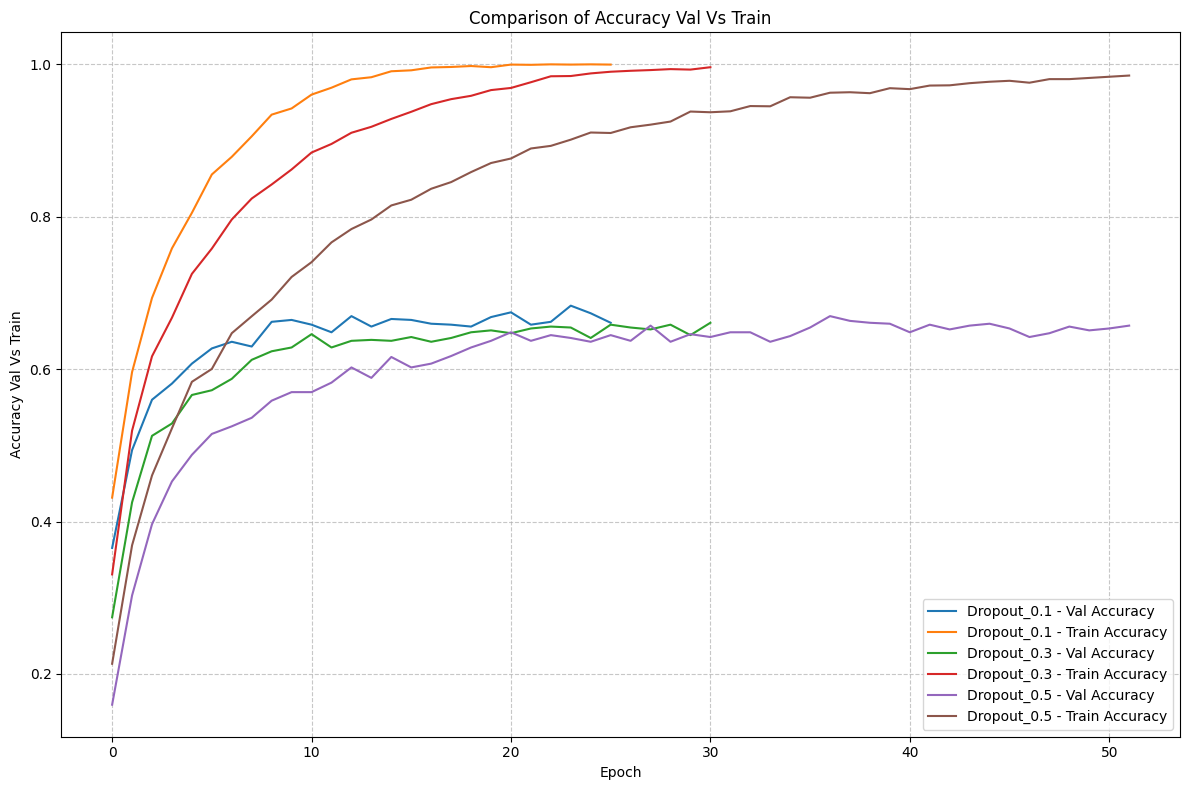

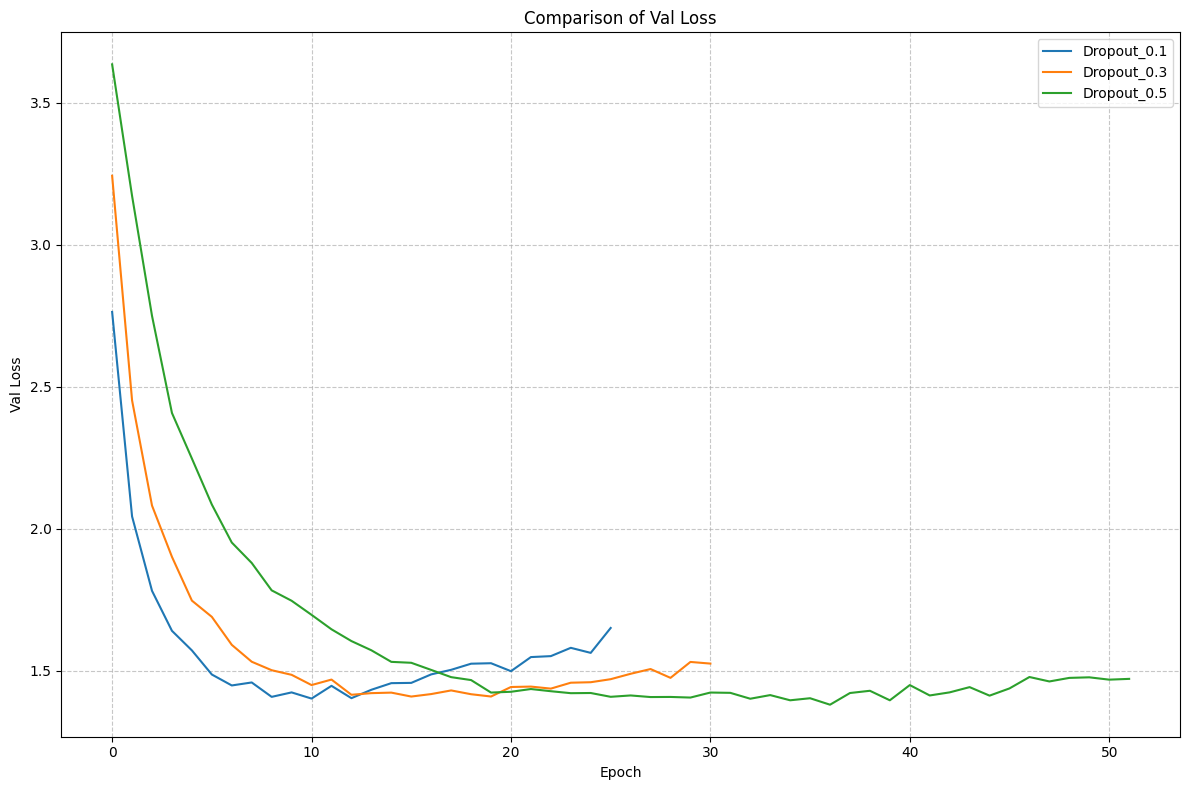

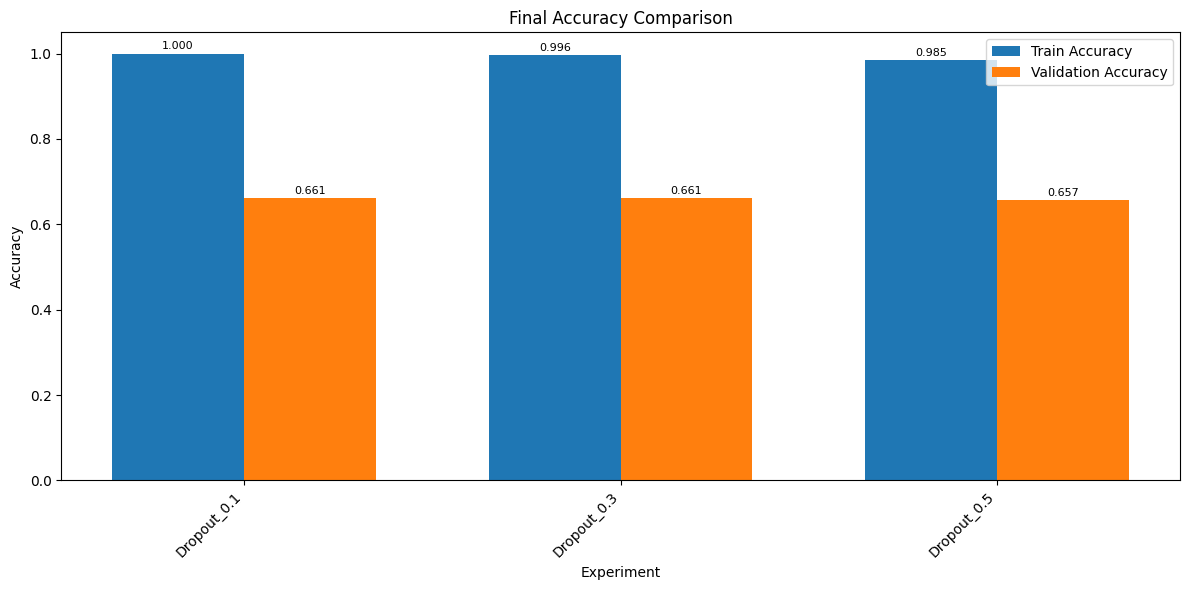


--- Mejor Modelo Después del Ajuste de Dropout ---
Nombre: Dropout_0.1
Precisión de Validación: 0.6608
Dropout Rate: 0.1
Configuración Completa:
  learning_rate: 0.001
  l2_lambda: 0.0001
  dropout_rate: 0.1
  use_batch_norm: False
  epochs: 4000
  batch_size: 64
  optimizer: adam
  lr_schedule: exponential
  early_stopping_patience: 15
  name: Dropout_0.1
  model: <src.improved_neural_network.ImprovedNeuralNetwork object at 0x70d0fd5f4f20>
  final_train_loss: 0.02018109722402314
  final_train_accuracy: 0.999687206756334
  final_val_loss: 1.65058578055422
  final_val_accuracy: 0.6608478802992519
  training_time: 11.681177139282227


In [27]:
print("\nGraficando resultados del ajuste de Dropout...")
plot_experiment_results(dropout_tuning_results, metric='accuracy_val_vs_train')
plot_experiment_results(dropout_tuning_results, metric='val_loss')
compare_final_metrics(dropout_tuning_results)

best_dropout_tuned_model = max(dropout_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de Dropout ---")
print(f"Nombre: {best_dropout_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_dropout_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"Dropout Rate: {best_dropout_tuned_model.get('dropout_rate', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_dropout_tuned_model.items():
    if key not in ['history']:
        print(f"  {key}: {value}")

In [28]:
batch_sizes_to_test = [32, 64, 128]
batch_size_tuning_experiments = []

best_dropout = best_dropout_tuned_model['dropout_rate']

config['dropout_rate'] = best_dropout

for bs_value in batch_sizes_to_test:
    batch_size_tuning_experiments.append(config.copy())
    batch_size_tuning_experiments[-1]['batch_size'] = bs_value
    batch_size_tuning_experiments[-1]['name'] = f"BatchSize_{bs_value}"

batch_size_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    batch_size_tuning_experiments
)


Running experiment: BatchSize_32
Epoch: [>                                                 ] 0% - train_loss: 0.0131 - train_acc: 0.9997 - val_loss: 1.8533 - val_acc: 0.6409 - lr: 0.0010
Early stopping triggered at epoch 25

Best result for BatchSize_32: val_loss = 1.4695, val_accuracy = 0.6471

Running experiment: BatchSize_64
Epoch: [>                                                 ] 0% - train_loss: 0.0248 - train_acc: 1.0000 - val_loss: 1.6306 - val_acc: 0.6696 - lr: 0.0010
Early stopping triggered at epoch 25

Best result for BatchSize_64: val_loss = 1.4602, val_accuracy = 0.6309

Running experiment: BatchSize_128
Epoch: [>                                                 ] 0% - train_loss: 0.0304 - train_acc: 0.9994 - val_loss: 1.5948 - val_acc: 0.6746 - lr: 0.0010
Early stopping triggered at epoch 31

Best result for BatchSize_128: val_loss = 1.4388, val_accuracy = 0.6596



Graficando resultados del ajuste de Batch Size...


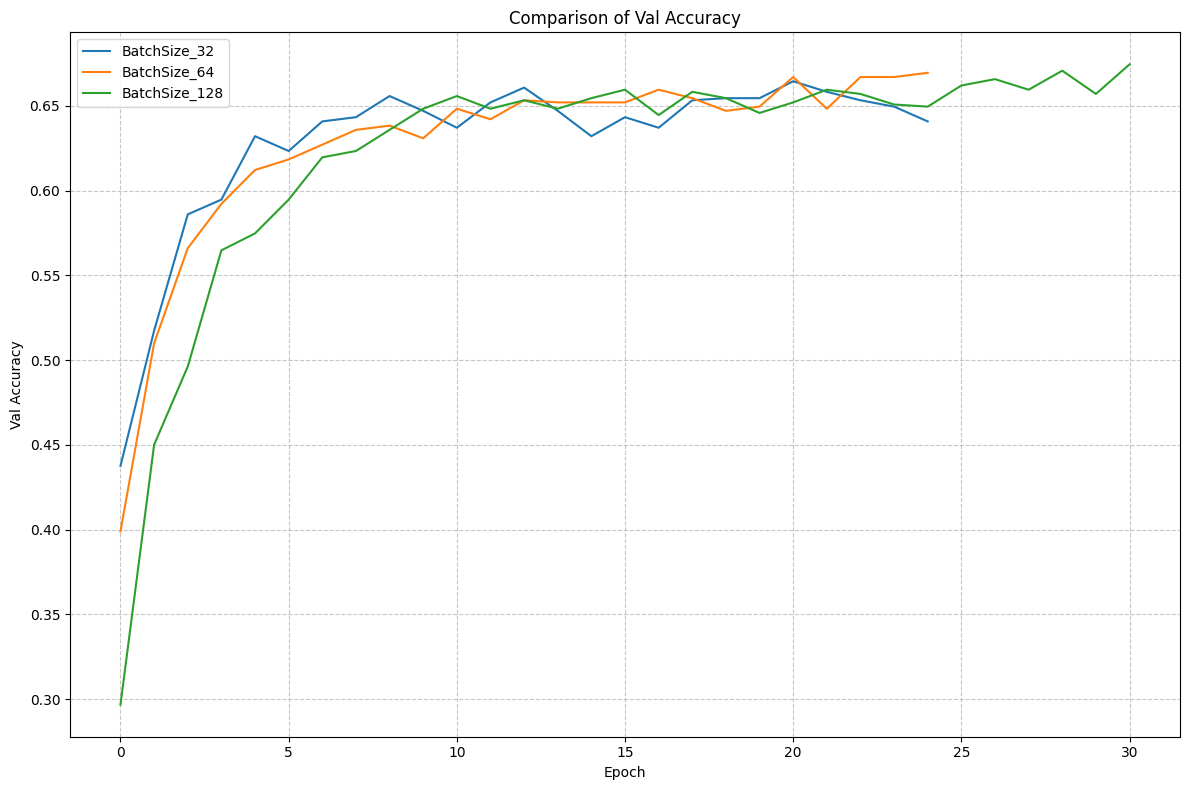

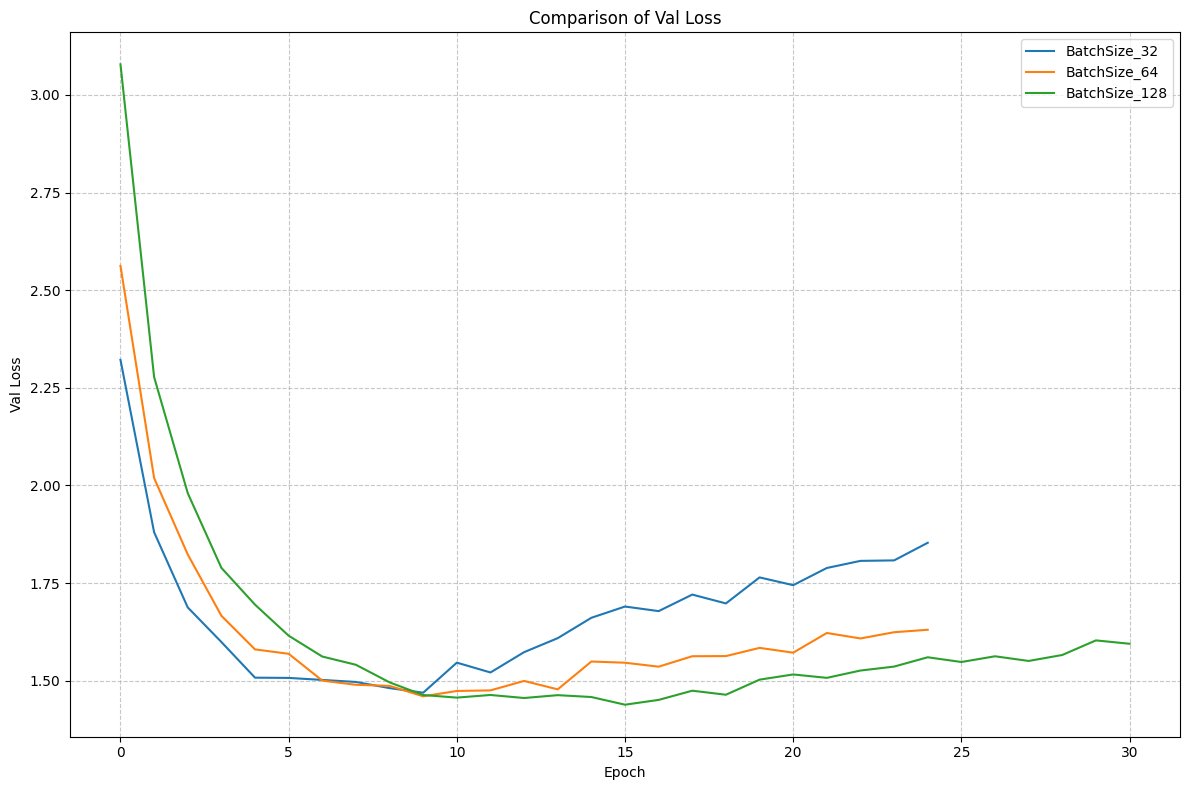

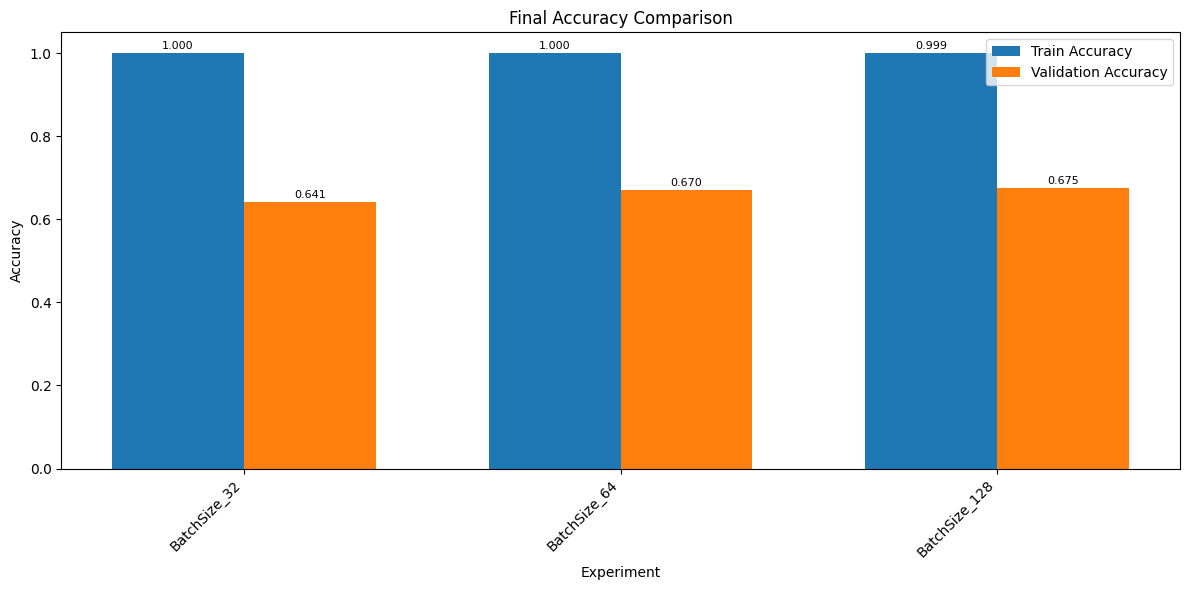


--- Mejor Modelo Después del Ajuste de Batch Size ---
Nombre: BatchSize_128
Precisión de Validación: 0.6746
Batch Size: 128
Configuración Completa:
  learning_rate: 0.001
  l2_lambda: 0.0001
  dropout_rate: 0.1
  use_batch_norm: False
  epochs: 4000
  batch_size: 128
  optimizer: adam
  lr_schedule: exponential
  early_stopping_patience: 15
  name: BatchSize_128
  model: <src.improved_neural_network.ImprovedNeuralNetwork object at 0x70d0fd8b4c50>
  final_train_loss: 0.03041992524748165
  final_train_accuracy: 0.9993744135126681
  final_val_loss: 1.5947655359172872
  final_val_accuracy: 0.6745635910224439
  training_time: 9.439747333526611


In [29]:

print("\nGraficando resultados del ajuste de Batch Size...")
plot_experiment_results(batch_size_tuning_results, metric='val_accuracy')
plot_experiment_results(batch_size_tuning_results, metric='val_loss')
compare_final_metrics(batch_size_tuning_results)

best_bs_tuned_model = max(batch_size_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de Batch Size ---")
print(f"Nombre: {best_bs_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_bs_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"Batch Size: {best_bs_tuned_model.get('batch_size', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_bs_tuned_model.items():
    if key not in ['history']:
        print(f"  {key}: {value}")


In [30]:
schedules_to_test = ['exponential', 'linear', None]

schedule_tuning_experiments = []

best_bs = best_bs_tuned_model['batch_size']

config['batch_size'] = best_bs

for sched in schedules_to_test:
    schedule_tuning_experiments.append(config.copy())
    schedule_tuning_experiments[-1]['lr_schedule'] = sched
    schedule_tuning_experiments[-1]['name'] = f"LRSchedule_{sched}"

schedule_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    schedule_tuning_experiments
)


Running experiment: LRSchedule_exponential
Epoch: [>                                                 ] 0% - train_loss: 0.0428 - train_acc: 0.9991 - val_loss: 1.6663 - val_acc: 0.6496 - lr: 0.0010
Early stopping triggered at epoch 29

Best result for LRSchedule_exponential: val_loss = 1.5176, val_accuracy = 0.6322

Running experiment: LRSchedule_linear
Epoch: [>                                                 ] 0% - train_loss: 0.0278 - train_acc: 1.0000 - val_loss: 1.6482 - val_acc: 0.6733 - lr: 0.0010
Early stopping triggered at epoch 33

Best result for LRSchedule_linear: val_loss = 1.5010, val_accuracy = 0.6509

Running experiment: LRSchedule_None
Epoch: [>                                                 ] 0% - train_loss: 0.0336 - train_acc: 0.9991 - val_loss: 1.6471 - val_acc: 0.6546 - lr: 0.0010
Early stopping triggered at epoch 31

Best result for LRSchedule_None: val_loss = 1.4648, val_accuracy = 0.6509



Graficando resultados del ajuste de LR Schedule...


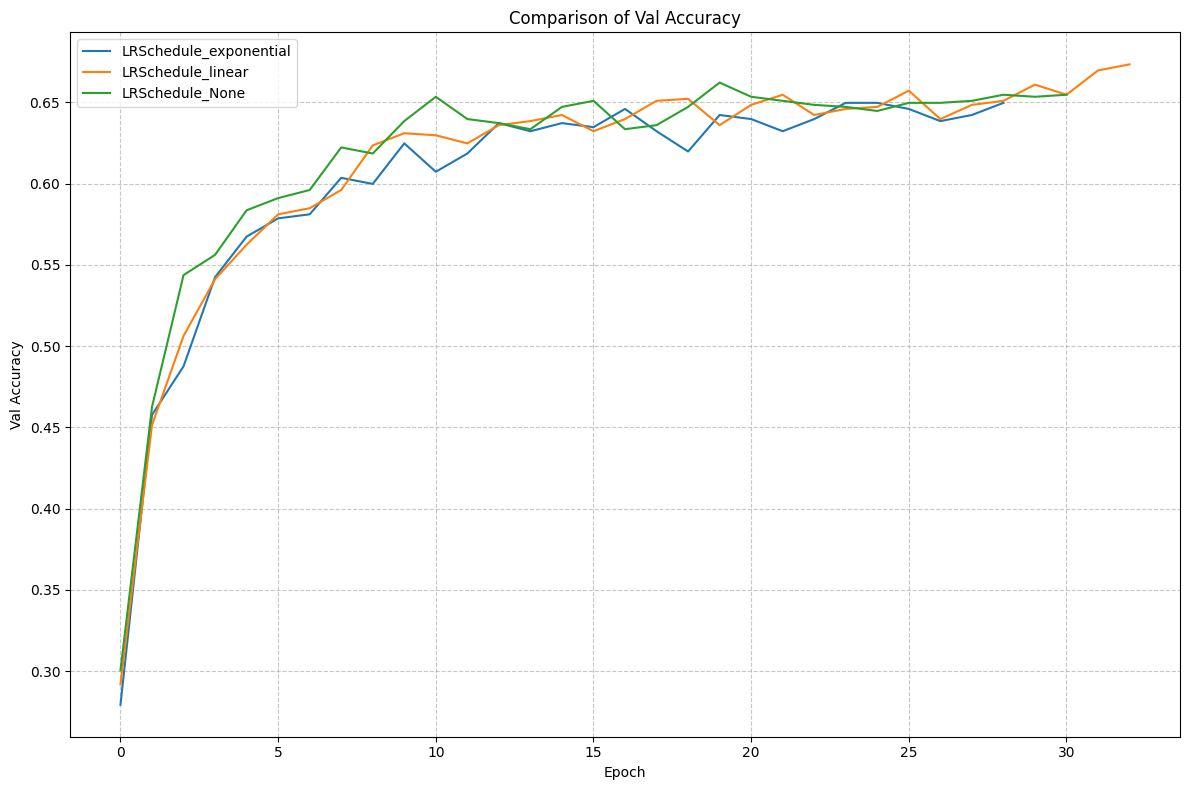

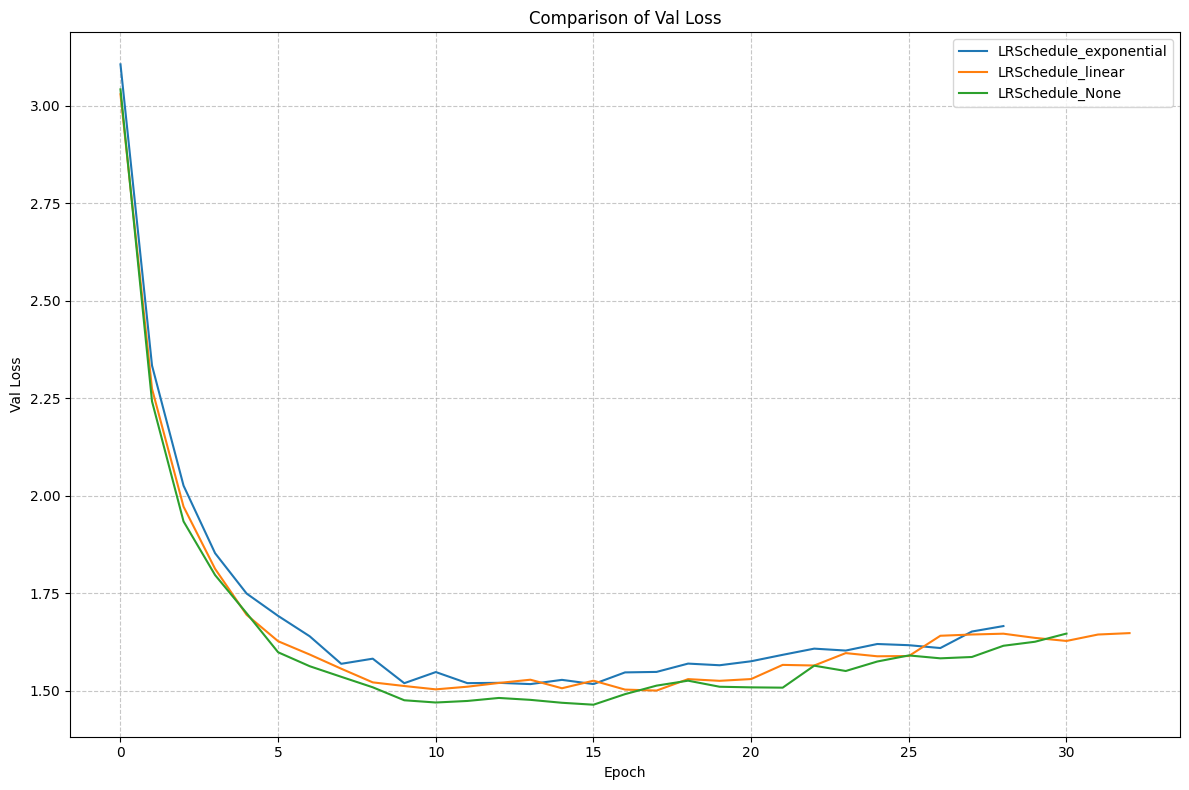

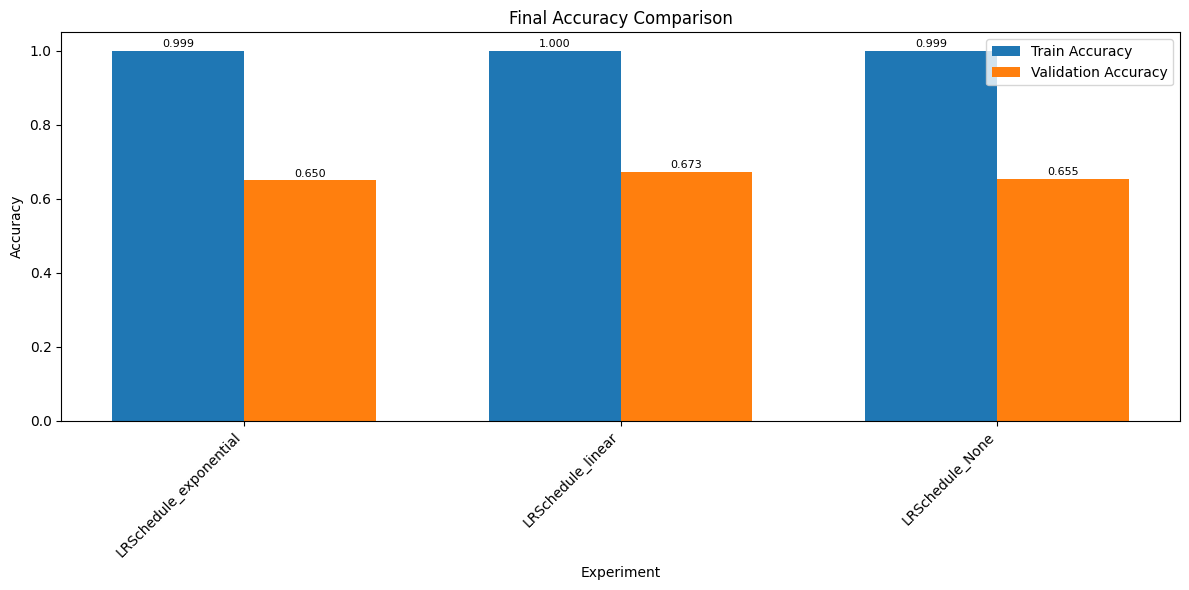


--- Mejor Modelo Después del Ajuste de LR Schedule ---
Nombre: LRSchedule_linear
Precisión de Validación: 0.6733
Schedule: linear
Configuración Completa:
  learning_rate: 0.001
  l2_lambda: 0.0001
  dropout_rate: 0.1
  use_batch_norm: False
  epochs: 4000
  batch_size: 128
  optimizer: adam
  lr_schedule: linear
  early_stopping_patience: 15
  name: LRSchedule_linear
  model: <src.improved_neural_network.ImprovedNeuralNetwork object at 0x70d0fd87e600>
  final_train_loss: 0.02781352558270429
  final_train_accuracy: 1.0
  final_val_loss: 1.648249769922454
  final_val_accuracy: 0.6733167082294265
  training_time: 10.584905862808228


In [31]:
print("\nGraficando resultados del ajuste de LR Schedule...")
plot_experiment_results(schedule_tuning_results, metric='val_accuracy')
plot_experiment_results(schedule_tuning_results, metric='val_loss')
compare_final_metrics(schedule_tuning_results)

best_sched_tuned_model = max(schedule_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de LR Schedule ---")
print(f"Nombre: {best_sched_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_sched_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"Schedule: {best_sched_tuned_model.get('lr_schedule', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_sched_tuned_model.items():
    if key not in ['history']:
        print(f"  {key}: {value}")


In [32]:
final_model = best_sched_tuned_model['model']
y_pred_test = final_model.forward(X_test, training=False)
test_loss = final_model.cross_entropy_loss(y_test, y_pred_test)
test_accuracy = final_model.accuracy(y_test, y_pred_test)

print(f"\nFinal model performance on test set:")
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_accuracy:.4f}")

conf_matrix = final_model.confusion_matrix(y_test, y_pred_test)

model_M1 = final_model
save_model(model_M1, "model_M1.pkl")


Final model performance on test set:
Test loss: 1.5488, test accuracy: 0.6414
Model successfully saved to modelos/model_M1.pkl


### 4. Desarrollo de una Red Neuronal con PyTorch
- Utilizando PyTorch, entrenar una red neuronal con la arquitectura y los hiperparámetros hallados en el ejercicio anterior. Llmaremos a este modelo M2.
- Utilizando PyTorch, explorar cambios en la cantidad de capas ocultas y unidades ocultas por capa, y determinar la configuración que funcione mejor. LLamaremos a este modelo M3.
- Utilizando PyTorch, encontrar una arquitectura (capas ocultas y unidades por
capa) que produzca overfitting. Llamaremos a este modelo M4.
Comparar la performance sobre el conjunto de test de los siguientes cuatro modelos:
    1. El modelo base de implementación propia (M0).
    2. La mejor arquitectura obtenida con la implementación propia (M1).
    3. Modelo en PyTorch, usando la misma arquiterctura e hiperparámetros que en la implementación propia (M2).
    4. La mejor arquitectura obtenida en PyTorch (M3).
    5. Una arquitectura en PyTorch con sobreajuste (M4).

In [33]:
print("\n4.a) Cargando el modelo base (M0) de implementación propia...")
model_M0 = load_model("model_M0.pkl")

test_pred_M0 = model_M0.forward(X_test)  
test_loss_M0 = model_M0.cross_entropy_loss(y_test, test_pred_M0) 
test_acc_M0 = model_M0.accuracy(y_test, test_pred_M0)
print(f"Modelo M0 en test: Accuracy={test_acc_M0:.4f}, Loss={test_loss_M0:.4f}")


4.a) Cargando el modelo base (M0) de implementación propia...
Model successfully loaded from modelos/model_M0.pkl
Modelo M0 en test: Accuracy=0.5814, Loss=1.8024


In [34]:
print("\n4.b) Cargando la mejor arquitectura de implementación propia (M1)...")
model_M1 = load_model("model_M1.pkl")

test_pred_M1 = model_M1.forward(X_test)  
test_loss_M1 = model_M1.cross_entropy_loss(y_test, test_pred_M1) 
test_acc_M1 = model_M1.accuracy(y_test, test_pred_M1)
print(f"Modelo M1 en test: Accuracy={test_acc_M1:.4f}, Loss={test_loss_M1:.4f}")


4.b) Cargando la mejor arquitectura de implementación propia (M1)...
Model successfully loaded from modelos/model_M1.pkl
Modelo M1 en test: Accuracy=0.5784, Loss=1.8049


In [35]:
print("\n4.c) Implementando modelo en PyTorch con misma arquitectura (M2)...")
model_M2 = PyTorchNetwork(
    layer_sizes=layer_sizes,
    learning_rate=0.001,
    l2_lambda=0.0005,
    dropout_rate=0.2
)

print("Entrenando modelo M2...")
history_M2 = model_M2.train_model(
    X_train, y_train, X_val, y_val,
    epochs=1000, batch_size=64,
    early_stopping_patience=10,
    verbose=1
)

save_model(model_M2, "model_M2.pkl")

test_acc_M2, test_loss_M2, test_pred_M2 = model_M2.evaluate(X_test, y_test)
print(f"Modelo M2 en test: Accuracy={test_acc_M2:.4f}, Loss={test_loss_M2:.4f}")


4.c) Implementando modelo en PyTorch con misma arquitectura (M2)...
Entrenando modelo M2...
Epoch: [=>                                                ] 3% - train_loss: 0.6258 - train_acc: 0.8205 - val_loss: 1.5350 - val_acc: 0.6247
Early stopping triggered at epoch 36

Model successfully saved to modelos/model_M2.pkl
Modelo M2 en test: Accuracy=0.6164, Loss=1.6651


In [36]:
print("\n4.d) Explorando diferentes arquitecturas con PyTorch...")

architectures = [
    {'name': 'One Hidden Layer (200)', 'layers': [input_size, 200, output_size]},
    {'name': 'Two Hidden Layers (100, 80)', 'layers': [input_size, 100, 80, output_size]},
    {'name': 'Three Hidden Layers (120, 80, 60)', 'layers': [input_size, 120, 80, 60, output_size]},
    {'name': 'Wide Network (200, 150)', 'layers': [input_size, 200, 150, output_size]},
    {'name': 'Deep Network (100, 80, 60, 40)', 'layers': [input_size, 100, 80, 60, 40, output_size]}
]

architecture_results = []

for arch in architectures:
    print(f"\nEntrenando {arch['name']}...")
    
    model = PyTorchNetwork(
        layer_sizes=arch['layers'],
        learning_rate=0.001,
        l2_lambda=0.0005,
        dropout_rate=0.2
    )
    
    history = model.train_model(
        X_train, y_train, X_val, y_val,
        epochs=50, batch_size=64,
        early_stopping_patience=10,
        verbose=1
    )
    
    test_acc, test_loss, _ = model.evaluate(X_test, y_test)
    
    arch_result = arch.copy()
    arch_result.update({
        'model': model,
        'history': history,
        'test_accuracy': test_acc,
        'test_loss': test_loss
    })
    
    architecture_results.append(arch_result)
    print(f"Arquitectura {arch['name']} en test: Accuracy={test_acc:.4f}, Loss={test_loss:.4f}")

best_arch = max(architecture_results, key=lambda x: x['test_accuracy'])
print(f"\nMejor arquitectura: {best_arch['name']}")
print(f"Test accuracy: {best_arch['test_accuracy']:.4f}")

model_M3 = best_arch['model']
test_acc_M3 = best_arch['test_accuracy']
test_loss_M3 = best_arch['test_loss']

save_model(model_M3, "model_M3.pkl")



4.d) Explorando diferentes arquitecturas con PyTorch...

Entrenando One Hidden Layer (200)...
Epoch: [===========================>                      ] 56% - train_loss: 0.3119 - train_acc: 0.9343 - val_loss: 1.4980 - val_acc: 0.6446
Early stopping triggered at epoch 28

Arquitectura One Hidden Layer (200) en test: Accuracy=0.6374, Loss=1.5968

Entrenando Two Hidden Layers (100, 80)...
Epoch: [================================>                 ] 66% - train_loss: 0.6970 - train_acc: 0.8029 - val_loss: 1.5538 - val_acc: 0.6209
Early stopping triggered at epoch 33

Arquitectura Two Hidden Layers (100, 80) en test: Accuracy=0.6204, Loss=1.6679

Entrenando Three Hidden Layers (120, 80, 60)...
Epoch: [=============================>                    ] 60% - train_loss: 0.8226 - train_acc: 0.7535 - val_loss: 1.6741 - val_acc: 0.5885
Early stopping triggered at epoch 30

Arquitectura Three Hidden Layers (120, 80, 60) en test: Accuracy=0.5844, Loss=1.7637

Entrenando Wide Network (200, 150)

In [37]:
print("\n4.e) Implementando arquitectura con overfitting...")

model_M4 = PyTorchNetwork(
    layer_sizes=[input_size, 300, 200, 150, output_size],
    learning_rate=0.001,
    l2_lambda=0.0,
    dropout_rate=0.0 
)

print("Entrenando modelo M4 (overfitting)...")
history_M4 = model_M4.train_model(
    X_train, y_train, X_val, y_val,
    epochs=2000, batch_size=64,
    early_stopping_patience=None,
    verbose=1
)

save_model(model_M4, "model_M4.pkl")

train_acc_M4, train_loss_M4, _ = model_M4.evaluate(X_train, y_train)
test_acc_M4, test_loss_M4, test_pred_M4 = model_M4.evaluate(X_test, y_test)

print(f"Modelo M4 (overfitting) en train: Accuracy={train_acc_M4:.4f}, Loss={train_loss_M4:.4f}")
print(f"Modelo M4 (overfitting) en test: Accuracy={test_acc_M4:.4f}, Loss={test_loss_M4:.4f}")
print(f"Diferencia entre train y test accuracy: {train_acc_M4 - test_acc_M4:.4f}")


4.e) Implementando arquitectura con overfitting...
Entrenando modelo M4 (overfitting)...
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 10.4639 - val_acc: 0.6421
Model successfully saved to modelos/model_M4.pkl
Modelo M4 (overfitting) en train: Accuracy=1.0000, Loss=0.0000
Modelo M4 (overfitting) en test: Accuracy=0.6254, Loss=11.1746
Diferencia entre train y test accuracy: 0.3746


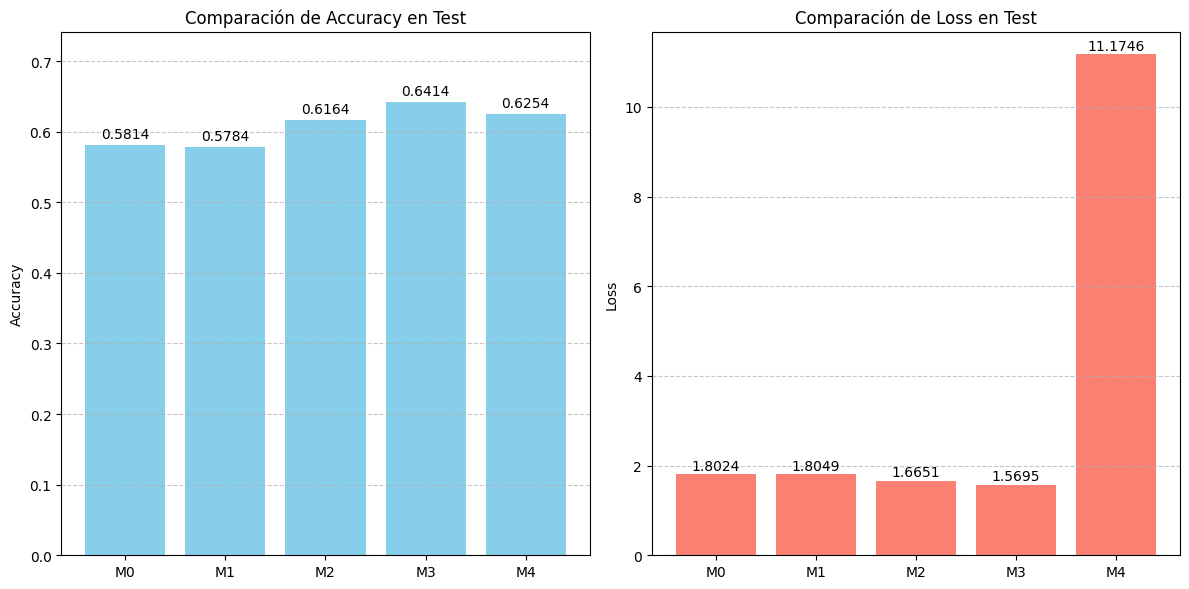


Tabla comparativa de modelos:
Modelo Descripción                              Test Accuracy   Test Loss      
--------------------------------------------------------------------------------
M0    Modelo base implementación propia        0.5814          1.8024         
M1    Mejor modelo implementación propia       0.5784          1.8049         
M2    PyTorch misma arquitectura que M1        0.6164          1.6651         
M3    Mejor arquitectura PyTorch (Wide Network (200, 150)) 0.6414          1.5695         
M4    PyTorch con overfitting                  0.6254          11.1746        

El mejor modelo global es: M3 - Mejor arquitectura PyTorch (Wide Network (200, 150))
Test accuracy: 0.6414


In [38]:
models_comparison = {
    'M0': {'name': 'Modelo base implementación propia', 'test_acc': test_acc_M0, 'test_loss': test_loss_M0},
    'M1': {'name': 'Mejor modelo implementación propia', 'test_acc': test_acc_M1, 'test_loss': test_loss_M1},
    'M2': {'name': 'PyTorch misma arquitectura que M1', 'test_acc': test_acc_M2, 'test_loss': test_loss_M2},
    'M3': {'name': f'Mejor arquitectura PyTorch ({best_arch["name"]})', 'test_acc': test_acc_M3, 'test_loss': test_loss_M3},
    'M4': {'name': 'PyTorch con overfitting', 'test_acc': test_acc_M4, 'test_loss': test_loss_M4}
}

plt.figure(figsize=(12, 6))
models = list(models_comparison.keys())
accuracies = [models_comparison[m]['test_acc'] for m in models]
losses = [models_comparison[m]['test_loss'] for m in models]

plt.subplot(1, 2, 1)
bars = plt.bar(models, accuracies, color='skyblue')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.4f}', ha='center', fontsize=10)

plt.title('Comparación de Accuracy en Test')
plt.ylabel('Accuracy')
plt.ylim(0, max(accuracies) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
bars = plt.bar(models, losses, color='salmon')

for bar, loss in zip(bars, losses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{loss:.4f}', ha='center', fontsize=10)

plt.title('Comparación de Loss en Test')
plt.ylabel('Loss')
plt.ylim(0, max(losses) + 0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\nTabla comparativa de modelos:")
print("=" * 80)
print(f"{'Modelo':<5} {'Descripción':<40} {'Test Accuracy':<15} {'Test Loss':<15}")
print("-" * 80)
for model_id, model_info in models_comparison.items():
    print(f"{model_id:<5} {model_info['name']:<40} {model_info['test_acc']:<15.4f} {model_info['test_loss']:<15.4f}")
print("=" * 80)

best_model_id = max(models_comparison.keys(), key=lambda m: models_comparison[m]['test_acc'])
print(f"\nEl mejor modelo global es: {best_model_id} - {models_comparison[best_model_id]['name']}")
print(f"Test accuracy: {models_comparison[best_model_id]['test_acc']:.4f}")

### 5. Desafío
- Utilizando el modelo que considere que sea el mejor, predecir las probabilidades a-posteriori de cada clase del dataset X_COMP.npy y generar un archivo .csv con las predicciones llamado Apellido_Nombre_predicciones.csv. El archivo predicciones.csv debe tener una fila por muestra y las columnas deben ser las probabilidades a posteriori de cada clase.

In [75]:
model = PyTorchNetwork(
    layer_sizes=best_arch['layers'],
    learning_rate=0.001,
    l2_lambda=0.0005,
    dropout_rate=0.2
)

X_train, _, X_test, y_train, _, y_test = stratified_split(
    X_images / 255.0 , y_images, train_ratio=0.8, val_ratio=0.0, test_ratio=0.2, random_state=42
)

history = model.train_model(
    X_train, y_train, X_test, y_test,
    epochs=50, batch_size=64,
    early_stopping_patience=10,
    verbose=2
)

save_model(model, "model_final.pkl")

Epoch: [========================>                         ] 50% - train_loss: 0.3653 - train_acc: 0.9002 - val_loss: 1.4300 - val_acc: 0.6713
Early stopping triggered at epoch 25


Training completed in 4.94 seconds
Final train loss: 0.3653, train accuracy: 0.9002
Final val loss: 1.4300, val accuracy: 0.6713
Best epoch: 15
Best val loss: 1.3744, best val accuracy: 0.6533
Model successfully saved to modelos/model_final.pkl


In [76]:
import pandas as pd
import torch


X_COMP = np.load("data/X_COMP.npy")
X_COMP = X_COMP / 255.0

model = load_model("model_final.pkl")  

probabilidades = model.forward(X_COMP)

if isinstance(probabilidades, torch.Tensor):
    probabilidades = probabilidades.detach().numpy()

columnas = [f"Clase_{i}" for i in range(probabilidades.shape[1])]

df_predicciones = pd.DataFrame(probabilidades, columns=columnas)
df_predicciones.to_csv("Ostrovsky_Eliana_predicciones.csv", index=False)

Model successfully loaded from modelos/model_final.pkl


In [77]:
import pandas as pd
df = pd.read_csv("Ostrovsky_Eliana_predicciones.csv")
df.describe()

,Clase_0,Clase_1,Clase_2,Clase_3,Clase_4,Clase_5,Clase_6,Clase_7,Clase_8,Clase_9,...,Clase_39,Clase_40,Clase_41,Clase_42,Clase_43,Clase_44,Clase_45,Clase_46,Clase_47,Clase_48
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,...,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,2.611920e-02,2.064344e-02,2.870703e-02,1.082913e-02,2.262685e-02,3.344197e-02,1.169238e-02,1.991044e-02,1.906106e-02,2.816314e-02,...,1.438248e-02,1.981343e-02,1.901835e-02,1.040640e-02,1.322219e-02,1.333118e-02,1.332052e-02,1.855060e-02,1.934724e-02,2.121775e-02
std,1.265705e-01,1.271555e-01,1.424891e-01,8.408357e-02,1.325127e-01,1.254757e-01,7.982784e-02,1.096305e-01,9.785683e-02,1.416274e-01,...,7.463717e-02,9.341968e-02,1.027030e-01,7.704660e-02,8.966322e-02,9.456260e-02,9.432845e-02,1.138361e-01,1.216038e-01,9.369880e-02
min,1.913551e-14,3.952132e-13,2.416978e-20,6.205933e-16,6.106114e-17,6.349301e-15,6.535887e-18,1.050841e-16,4.517150e-17,5.916345e-16,...,1.149129e-16,2.420128e-13,6.180109e-16,4.182995e-18,6.398054e-12,1.006873e-14,6.866743e-17,1.565159e-17,5.682552e-17,1.224745e-13
25%,1.485916e-06,2.117023e-07,1.686026e-09,2.757832e-08,2.399356e-08,2.078835e-05,1.041366e-07,2.818434e-07,2.946018e-06,7.570915e-07,...,6.702225e-07,8.572146e-06,4.500706e-07,1.963927e-08,6.422549e-07,7.699596e-07,2.057488e-07,3.639618e-08,2.944509e-08,2.389881e-06
50%,5.507247e-05,6.290297e-06,9.379176e-07,2.847443e-06,1.828056e-06,4.111452e-04,1.079931e-05,2.398097e-05,1.116990e-04,4.143436e-05,...,4.739418e-05,1.948845e-04,2.710789e-05,2.464822e-06,2.245091e-05,3.406217e-05,9.377187e-06,3.999824e-06,3.144613e-06,1.814235e-04
75%,1.077600e-03,1.322927e-04,1.187025e-04,1.773927e-04,1.144254e-04,5.111172e-03,3.633786e-04,5.446401e-04,1.574888e-03,9.738120e-04,...,1.372197e-03,2.995253e-03,6.986719e-04,1.400317e-04,3.829176e-04,4.621152e-04,3.018631e-04,2.032239e-04,1.175859e-04,3.069374e-03
max,9.992557e-01,9.999903e-01,9.955663e-01,9.998017e-01,9.999750e-01,9.898649e-01,9.992662e-01,9.908195e-01,9.842175e-01,9.999827e-01,...,8.775084e-01,9.916810e-01,9.849724e-01,9.991148e-01,9.854695e-01,9.995863e-01,9.990161e-01,9.998465e-01,9.998864e-01,9.968513e-01
